In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats
import warnings
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.model_selection import TimeSeriesSplit, learning_curve
warnings.filterwarnings('ignore')

In [2]:
Df = pd.read_csv(r"C:\Users\acksh\OneDrive\Desktop\MSAI\Machine Learning\Final_project\data\owid-co2-data.csv")
Df.head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
Df.describe()

,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50191.000000,4.101900e+04,1.525100e+04,28863.000000,25358.000000,29137.000000,26981.000000,26002.000000,23585.000000,23285.000000,...,2108.000000,41001.000000,38060.000000,41001.000000,41001.000000,38060.000000,37410.000000,37236.000000,4535.000000,4535.000000
mean,1919.883067,5.686141e+07,3.300495e+11,7.767746,0.059036,415.698178,6.208882,43.104462,535.581202,7.214604,...,7.512655,2.269285,0.003026,0.007670,0.011023,0.000509,488.542225,316.133529,-7.232399,20.524440
std,65.627296,3.199905e+08,3.086383e+12,62.595292,0.120328,1945.843973,62.322553,1729.939596,2202.219657,99.347980,...,17.671054,9.315325,0.016519,0.043694,0.061901,0.003043,2392.579910,1839.602293,250.640012,52.744956
min,1750.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,-1977.750000,-100.000000,-99.693000,-2325.500000,...,0.000000,-0.810000,-0.001000,0.000000,-0.001000,0.000000,-14.961000,0.000000,-2195.952000,-98.849000
25%,1875.000000,3.273130e+05,7.874038e+09,0.000000,0.000000,0.374000,-0.005000,-1.102500,6.418000,-0.908000,...,0.204750,0.004000,0.000000,0.000000,0.000000,0.000000,1.835000,0.235000,-3.179500,-6.168000
50%,1924.000000,2.289522e+06,2.743861e+10,0.000000,0.001000,4.990000,0.044000,3.803500,27.691000,0.078000,...,0.838000,0.078000,0.000000,0.000000,0.000000,0.000000,15.007500,2.371000,1.518000,8.701000
75%,1974.000000,9.862459e+06,1.212627e+11,0.486000,0.075750,53.273000,1.002000,10.890750,123.959000,2.620000,...,3.211000,0.359000,0.001000,0.001000,0.001000,0.000000,78.242750,29.337500,9.153500,32.666000
max,2023.000000,8.091735e+09,1.301126e+14,1696.308000,2.484000,37791.570000,1865.208000,180870.000000,41416.480000,2340.184000,...,100.000000,100.000000,0.422000,1.161000,1.668000,0.085000,53816.852000,44114.785000,1798.999000,568.635000


In [4]:
def clean_country_dataset(file_path):
    """
    Removes rows where CO2 values are missing, removes the country column,
    and saves the file with the same name.
    
    Parameters:
    file_path (str): Path to the country-specific CSV file
    """
    try:
        # Read the dataset
        df = pd.read_csv(file_path)
        
        # Check initial shape
        initial_rows = df.shape[0]
        initial_cols = df.shape[1]
        
        # Remove rows where CO2 is null/NaN
        df_cleaned = df.dropna(subset=['co2'])
        
        # Remove the country column
        if 'country' in df_cleaned.columns:
            df_cleaned = df_cleaned.drop(columns=['country'])
        
        # Check final shape
        final_rows = df_cleaned.shape[0]
        final_cols = df_cleaned.shape[1]
        removed_rows = initial_rows - final_rows
        
        # Save back to the same file
        df_cleaned.to_csv(file_path, index=False)
        
        print(f"Processed {file_path}")
        print(f"  Removed {removed_rows} rows with missing CO2 values")
        print(f"  Removed country column")
        print(f"  Saved file with {final_rows} rows and {final_cols} columns\n")
        
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

In [5]:

output_dir = r"C:\Users\acksh\OneDrive\Desktop\MSAI\Machine Learning\Final_project\data\databycountry"

files = [f for f in os.listdir(output_dir) if f.endswith('.csv')]
    
print(f"Found {len(files)} country files to process")

# # Process each file
# for file in files:
#     file_path = os.path.join(output_dir, file)
#     clean_country_dataset(file_path)

print("All country files processed successfully")

Found 255 country files to process
All country files processed successfully


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def analyze_country_data(file_path, target_variable='co2'):
    """
    Perform extensive data analysis on a country-specific dataset to prepare for regression.
    
    Parameters:
    file_path (str): Path to the country CSV file
    target_variable (str): The target variable for regression analysis
    """
    # Load the data
    print(f"Analyzing data from: {file_path}")
    df = pd.read_csv(file_path)
    
    # Basic information
    print("\n===== BASIC DATASET INFORMATION =====")
    print(f"Dataset shape: {df.shape}")
    print(f"Time period covered: {df['year'].min()} to {df['year'].max()}")
    
    # Check for remaining missing values
    missing_values = df.isnull().sum()
    missing_pct = (missing_values / len(df)) * 100
    missing_summary = pd.DataFrame({
        'Missing Values': missing_values,
        'Percentage': missing_pct
    })
    print("\n===== MISSING VALUES ANALYSIS =====")
    print(missing_summary[missing_summary['Missing Values'] > 0].sort_values('Missing Values', ascending=False))
    
    # Check if target variable exists
    if target_variable not in df.columns:
        print(f"ERROR: Target variable '{target_variable}' not found in dataset!")
        return
    
    # Numeric columns (excluding year, iso_code and target variable)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'year' in numeric_cols:
        numeric_cols.remove('year')
    if 'iso_code' in numeric_cols:
        numeric_cols.remove('iso_code')
    
    
    # Distribution of target variable
    print(f"\n===== TARGET VARIABLE ANALYSIS: {target_variable} =====")
    print(f"Target variable statistics:\n{df[target_variable].describe()}")
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(121)
    sns.histplot(df[target_variable], kde=True)
    plt.title(f'Distribution of {target_variable}')
    
    plt.subplot(122)
    sns.lineplot(x='year', y=target_variable, data=df)
    plt.title(f'Trend of {target_variable} over time')
    plt.tight_layout()
    plt.show()
    
    # Check skewness of target variable
    skewness = stats.skew(df[target_variable].dropna())
    print(f"Skewness of {target_variable}: {skewness:.4f}")
    if abs(skewness) > 1:
        print(f"Recommendation: Consider log transformation of {target_variable} due to high skewness")
    
    # Create correlation matrix
    print("\n===== CORRELATION ANALYSIS =====")
    correlation_threshold = 0.7
    if target_variable in df.columns:
    # Create correlation matrix with target included
        corr_matrix = df[numeric_cols].corr()
    else:
        print(f"Warning: Target variable '{target_variable}' not found in columns")
        
    # Plot heatmap
    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    
    
    # Find features highly correlated with target
    target_corr = corr_matrix[target_variable].sort_values(ascending=False)
    print(f"Top correlations with {target_variable}:")
    print(target_corr[1:6])  # Skip the first one which is the target itself
    
    # Find highly correlated features
    print("\nStrongly correlated feature pairs (potential multicollinearity):")
    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= correlation_threshold:
                high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
                
    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
        high_corr_df = high_corr_df.sort_values('Correlation', ascending=False)
        print(high_corr_df[high_corr_df['Correlation']>0.9])
    else:
        print("No feature pairs with correlation >= 0.7 found.")
    
    if target_variable in numeric_cols:
        numeric_cols.remove(target_variable)
    
    # VIF analysis for multicollinearity
    print("\n===== MULTICOLLINEARITY ANALYSIS (VIF) =====")
    # Only include numeric features with sufficient non-null values
    vif_features = [col for col in numeric_cols 
                    if df[col].count() > df.shape[0] * 0.7]  # At least 70% non-null
    
    if len(vif_features) > 1:  # Need at least 2 features for VIF
        X = df[vif_features].dropna()
        
        # Calculate VIF
        vif_data = pd.DataFrame()
        vif_data["Feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        
        print(vif_data.sort_values("VIF", ascending=False))
        print("\nVIF > 10 suggests high multicollinearity")
        print("VIF > 5 suggests moderate multicollinearity")
    else:
        print("Not enough complete features for VIF analysis")
    
    # Feature importance using Random Forest
    print("\n===== FEATURE IMPORTANCE ANALYSIS =====")
    features_for_rf = [col for col in numeric_cols 
                      if df[col].count() > df.shape[0] * 0.7]
    
    if len(features_for_rf) > 0:
        # Create feature and target arrays
        X_rf = df[features_for_rf].fillna(df[features_for_rf].median())
        y_rf = df[target_variable].values
        
        # Train Random Forest for feature importance
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X_rf, y_rf)
        
        # Get feature importances
        importances = rf.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        # Print feature ranking
        print("Feature ranking:")
        for f in range(min(10, X_rf.shape[1])):
            print(f"{f+1}. {X_rf.columns[indices[f]]} ({importances[indices[f]]:.4f})")
        
        # Plot feature importances
        plt.figure(figsize=(10, 6))
        plt.title("Feature importances")
        plt.bar(range(min(10, X_rf.shape[1])), 
                importances[indices[:10]],
                align="center")
        plt.xticks(range(min(10, X_rf.shape[1])), 
                  [X_rf.columns[i] for i in indices[:10]], 
                  rotation=90)
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough complete features for Random Forest importance analysis")
    
    # Normalization/standardization assessment
    print("\n===== SCALING ASSESSMENT =====")
    # Statistics for numeric features
    stats_df = df[numeric_cols].describe().T
    stats_df['range'] = stats_df['max'] - stats_df['min']
    stats_df['coefficient_of_variation'] = stats_df['std'] / stats_df['mean']
    
    # Identify variables that need scaling
    stats_df['needs_scaling'] = stats_df['range'] > 10
    
    print("Features that may need scaling:")
    scaling_needed = stats_df[stats_df['needs_scaling']].sort_values('range', ascending=False)
    print(scaling_needed[['min', 'max', 'range']])
    
    # Check for outliers
    print("\n===== OUTLIER ANALYSIS =====")
    # Z-score method
    z_threshold = 3
    outlier_cols = []
    
    for col in numeric_cols:
        if df[col].count() > df.shape[0] * 0.5:  # At least 50% non-null
            z_scores = np.abs(stats.zscore(df[col].dropna()))
            outliers = (z_scores > z_threshold).sum()
            if outliers > 0:
                outlier_cols.append((col, outliers, outliers/df[col].count()*100))
    
    if outlier_cols:
        outlier_df = pd.DataFrame(outlier_cols, columns=['Feature', 'Outlier Count', 'Outlier Percentage'])
        outlier_df = outlier_df.sort_values('Outlier Count', ascending=False)
        print(outlier_df)
        
        # Plot top 3 features with most outliers
        if len(outlier_df) > 0:
            plt.figure(figsize=(15, 5))
            for i, col in enumerate(outlier_df['Feature'].head(min(3, len(outlier_df)))):
                plt.subplot(1, 3, i+1)
                sns.boxplot(y=df[col])
                plt.title(f'Boxplot of {col}')
            plt.tight_layout()
            plt.show()
    else:
        print("No significant outliers found using z-score method.")
    
    # Provide summary and recommendations
    print("\n===== SUMMARY AND RECOMMENDATIONS =====")
    
    # Recommendation for handling missing values
    high_missing = missing_summary[missing_summary['Percentage'] > 30].index.tolist()
    if high_missing:
        print(f"• Consider dropping features with high missing values: {', '.join(high_missing)}")
        
    # Recommendations for multicollinearity
    if high_corr_pairs:
        print("• Address multicollinearity by:")
        print("  - Use regularization techniques (Ridge or Lasso regression)")
        print("  - Consider dropping one feature from each highly correlated pair")
        print("  - Consider creating composite variables or performing dimension reduction")
    
    # Recommendations for feature importance
    if len(features_for_rf) > 0:
        top_features = [X_rf.columns[i] for i in indices[:5]]
        print(f"• Focus on top important features: {', '.join(top_features)}")
    
    # Recommendations for scaling
    if not scaling_needed.empty:
        print("• Apply appropriate scaling:")
        print("  - Use StandardScaler for features with normal distribution")
        print("  - Use MinMaxScaler for features with non-normal distribution")
        print("  - Consider log transformation for heavily skewed variables")
    
    # Recommendations for time-series aspects
    print("• For time-series aspects:")
    print("  - Check for autocorrelation in residuals")
    print("  - Consider including lagged variables")
    print("  - Test for stationarity in time-dependent variables")

    
    
    return df


Analyzing data from: C:\Users\acksh\OneDrive\Desktop\MSAI\Machine Learning\Final_project\data\databycountry\Afghanistan.csv

===== BASIC DATASET INFORMATION =====
Dataset shape: (75, 78)
Time period covered: 1949 to 2023

===== MISSING VALUES ANALYSIS =====
                                     Missing Values  Percentage
cumulative_other_co2                             75  100.000000
consumption_co2                                  75  100.000000
trade_co2                                        75  100.000000
share_global_other_co2                           75  100.000000
share_global_cumulative_other_co2                75  100.000000
other_industry_co2                               75  100.000000
other_co2_per_capita                             75  100.000000
consumption_co2_per_gdp                          75  100.000000
consumption_co2_per_capita                       75  100.000000
trade_co2_share                                  75  100.000000
co2_per_unit_energy                   

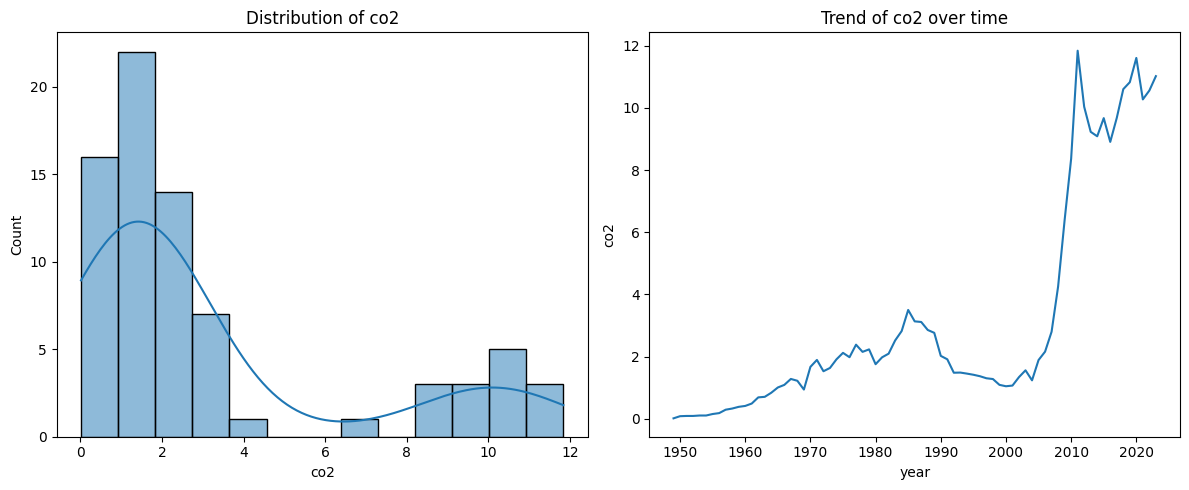

Skewness of co2: 1.3859
Recommendation: Consider log transformation of co2 due to high skewness

===== CORRELATION ANALYSIS =====


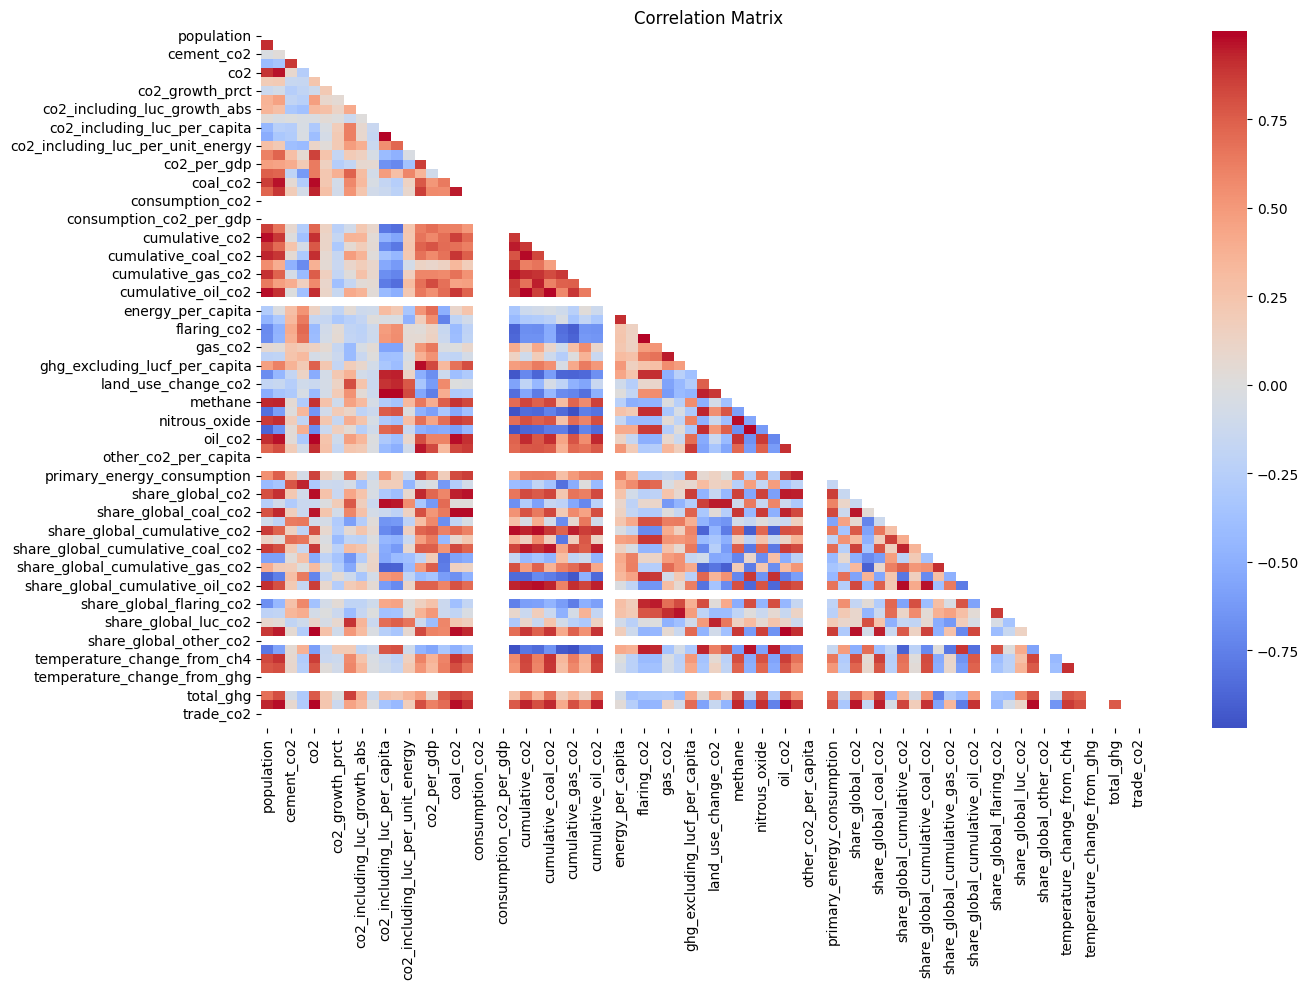

Top correlations with co2:
oil_co2                     0.993456
total_ghg_excluding_lucf    0.992642
share_global_oil_co2        0.988691
coal_co2                    0.979475
share_global_co2            0.972580
Name: co2, dtype: float64

Strongly correlated feature pairs (potential multicollinearity):
                               Feature 1                         Feature 2  \
212                       cumulative_co2                cumulative_oil_co2   
331                          flaring_co2            flaring_co2_per_capita   
437                              oil_co2              share_global_oil_co2   
69                                   co2                           oil_co2   
82                                   co2          total_ghg_excluding_lucf   
..                                   ...                               ...   
332                          flaring_co2                    ghg_per_capita   
245         cumulative_co2_including_luc  share_global_cumulative_coal_c

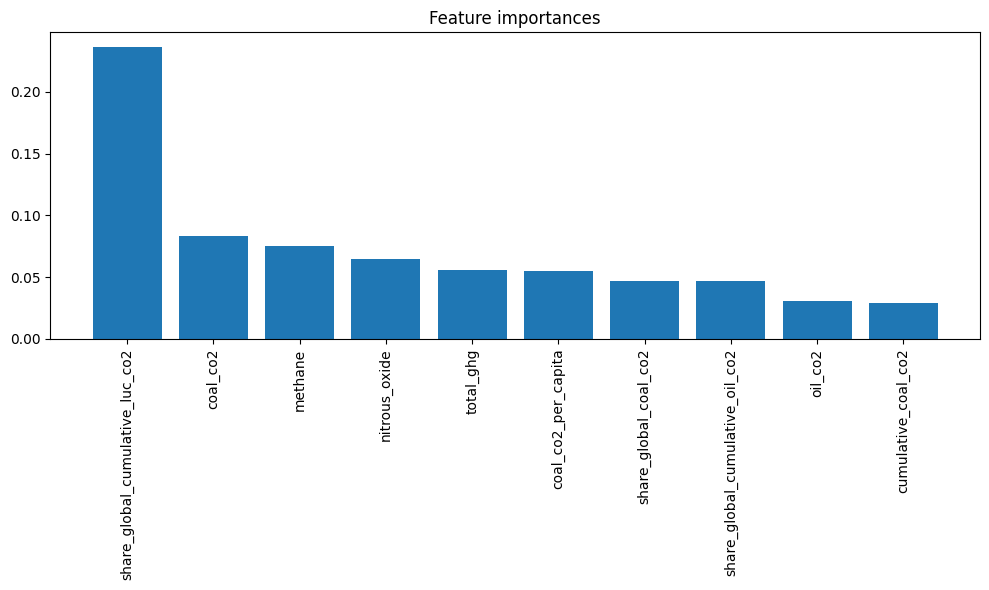


===== SCALING ASSESSMENT =====
Features that may need scaling:
                                        min           max         range
gdp                            7.919857e+09  7.308571e+10  6.516585e+10
population                     7.356890e+06  4.145476e+07  3.409787e+07
energy_per_capita              2.042310e+02  3.139185e+03  2.934954e+03
co2_including_luc_growth_prct -2.289960e+02  1.342009e+03  1.571005e+03
cumulative_co2_including_luc   6.250000e+00  6.005950e+02  5.943450e+02
co2_growth_prct               -2.678400e+01  4.750000e+02  5.017840e+02
cumulative_luc_co2             5.195030e+02  8.770220e+02  3.575190e+02
cumulative_co2                 1.500000e-02  2.368410e+02  2.368260e+02
cumulative_oil_co2             0.000000e+00  1.447850e+02  1.447850e+02
cumulative_coal_co2            1.500000e-02  6.316100e+01  6.314600e+01
primary_energy_consumption     4.428000e+00  4.200500e+01  3.757700e+01
co2_including_luc             -2.575000e+00  2.845200e+01  3.102700e+01


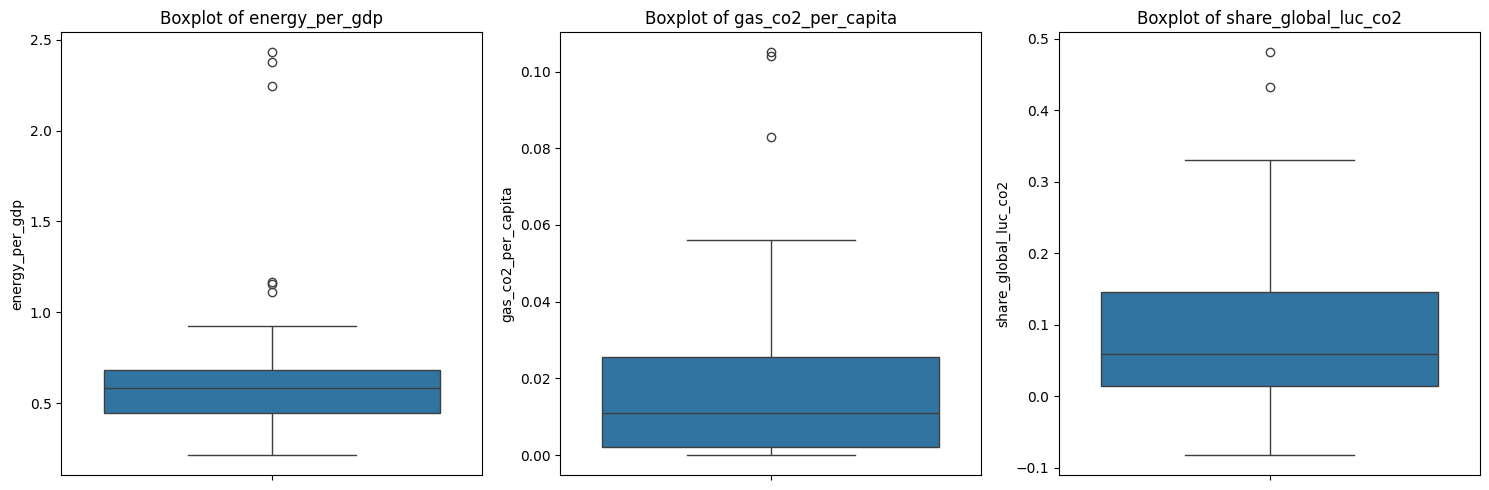


===== SUMMARY AND RECOMMENDATIONS =====
• Consider dropping features with high missing values: co2_including_luc_per_unit_energy, co2_per_unit_energy, consumption_co2, consumption_co2_per_capita, consumption_co2_per_gdp, cumulative_other_co2, energy_per_capita, energy_per_gdp, other_co2_per_capita, other_industry_co2, primary_energy_consumption, share_global_cumulative_other_co2, share_global_other_co2, trade_co2, trade_co2_share
• Address multicollinearity by:
  - Use regularization techniques (Ridge or Lasso regression)
  - Consider dropping one feature from each highly correlated pair
  - Consider creating composite variables or performing dimension reduction
• Focus on top important features: share_global_cumulative_luc_co2, coal_co2, methane, nitrous_oxide, total_ghg
• Apply appropriate scaling:
  - Use StandardScaler for features with normal distribution
  - Use MinMaxScaler for features with non-normal distribution
  - Consider log transformation for heavily skewed variables
• 

,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,1949,AFG,7356890.0,NaN,0.000,0.000,0.015,NaN,NaN,6.250,...,NaN,0.128,0.000,0.000,0.001,0.0,18.288,1.297,NaN,NaN
1,1950,AFG,7776182.0,9.421400e+09,0.000,0.000,0.084,0.070,475.000,7.316,...,NaN,0.128,0.000,0.000,0.001,0.0,19.447,1.453,NaN,NaN
2,1951,AFG,7879343.0,9.692280e+09,0.000,0.000,0.092,0.007,8.696,8.264,...,NaN,0.128,0.000,0.000,0.001,0.0,20.458,1.473,NaN,NaN
3,1952,AFG,7987783.0,1.001733e+10,0.000,0.000,0.092,0.000,0.000,9.192,...,NaN,0.128,0.000,0.000,0.001,0.0,21.356,1.484,NaN,NaN
4,1953,AFG,8096703.0,1.063052e+10,0.000,0.000,0.106,0.015,16.000,10.269,...,NaN,0.128,0.000,0.000,0.001,0.0,22.361,1.517,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2019,AFG,37856126.0,7.308571e+10,0.038,0.001,10.825,0.223,2.106,19.743,...,NaN,0.083,0.001,0.001,0.001,0.0,39.145,18.538,NaN,NaN
71,2020,AFG,39068978.0,7.141771e+10,0.061,0.002,11.606,0.781,7.213,16.833,...,NaN,0.083,0.001,0.001,0.001,0.0,37.833,18.633,NaN,NaN
72,2021,AFG,40000411.0,5.663885e+10,0.016,0.000,10.272,-1.334,-11.495,22.036,...,NaN,0.084,0.001,0.001,0.001,0.0,38.313,17.947,NaN,NaN
73,2022,AFG,40578846.0,5.330347e+10,0.016,0.000,10.558,0.286,2.784,25.863,...,NaN,0.084,0.001,0.001,0.001,0.0,39.485,18.355,NaN,NaN


In [9]:
analyze_country_data(os.path.join(output_dir,f"Afghanistan.csv"))

In [77]:

def analyze_selected_features(csv_file, feature_columns, target_variable, correlation_threshold=0.8):
    # Load data and select columns
    df = pd.read_csv(csv_file)
    columns_to_use = feature_columns + [target_variable]
    df_selected = df[columns_to_use].copy()
    
    # Drop rows with NaN in target
    df_selected = df_selected.dropna(subset=[target_variable])
    
    # Plot correlation matrix
    plt.figure(figsize=(12, 10))
    corr_matrix = df_selected.corr()
    
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.savefig('correlation_matrix.png')
    plt.show()
    
    # Find correlated pairs
    correlated_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= correlation_threshold:
                correlated_pairs.append((corr_matrix.columns[i], 
                                        corr_matrix.columns[j], 
                                        corr_matrix.iloc[i, j]))
    
    correlated_df = pd.DataFrame(correlated_pairs, columns=['Feature 1', 'Feature 2', 'Correlation'])
    correlated_df = correlated_df.sort_values('Correlation', ascending=False)
    print("Highly correlated feature pairs:")
    print(correlated_df)
    
    # Calculate VIF
    X = df_selected.drop(columns=[target_variable])
    X = X.fillna(X.mean())  # Handle any remaining NaN values
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif_data = vif_data.sort_values("VIF", ascending=False)
    print("\nVariance Inflation Factors:")
    print(vif_data)
    
    # Feature importance
    X = df_selected.drop(columns=[target_variable])
    y = df_selected[target_variable]
    
    X_filled = X.fillna(X.mean())
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_filled, y)
    
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': model.feature_importances_
    })
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    print("\nFeature Importance Ranking:")
    print(feature_importance)
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title('Feature Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    


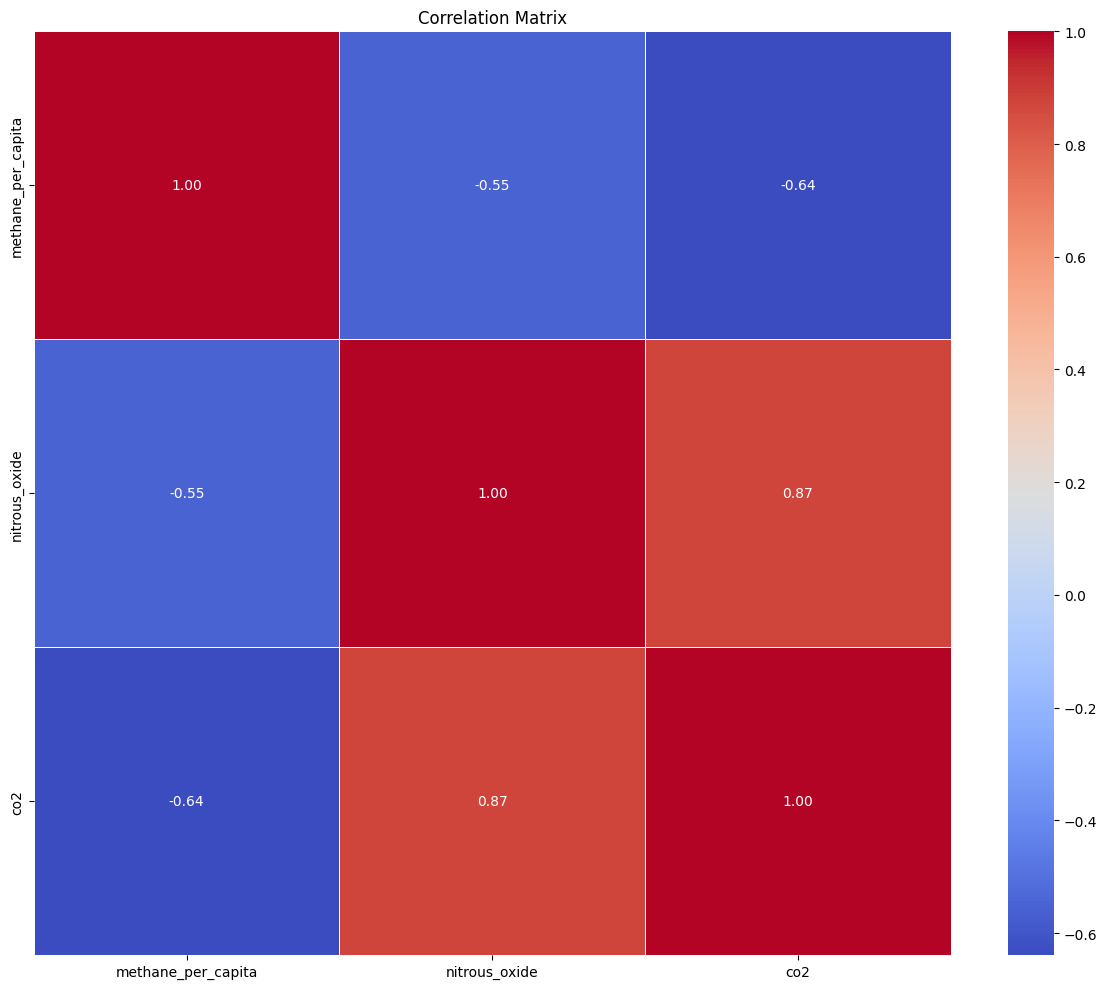

Highly correlated feature pairs:
       Feature 1 Feature 2  Correlation
0  nitrous_oxide       co2     0.872653

Variance Inflation Factors:
              Feature       VIF
0  methane_per_capita  5.532074
1       nitrous_oxide  5.532074

Feature Importance Ranking:
              Feature  Importance
1       nitrous_oxide    0.943615
0  methane_per_capita    0.056385


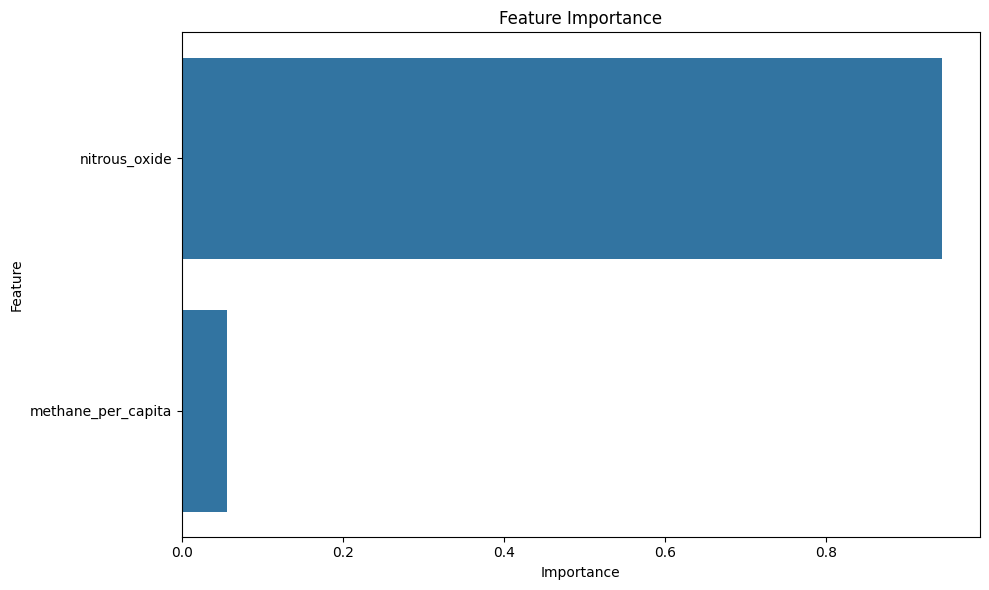

In [86]:


analyze_selected_features(os.path.join(output_dir,f'Afghanistan.csv'),[
'methane_per_capita','nitrous_oxide'
]
,target_variable='co2' )

In [76]:

def apply_pca_and_save(csv_file, column_names, target_variable, n_components, source_name,
                      component_prefix='PC'):
    """
    Apply PCA to specified columns in a CSV file and append the new component columns.
    
    Parameters:
    -----------
    csv_file : str
        Path to the CSV file
    column_names : list
        List of column names to use for PCA
    target_variable : str
        Name of the target variable (not used in PCA but kept for reference)
    n_components : int
        Number of principal components to extract
    source_name : str
        Name of the source group (coal, gas, etc.)
    component_prefix : str, optional
        Prefix for the new component columns, defaults to 'PC'
        
    Returns:
    --------
    DataFrame
        The modified DataFrame with new PCA component columns
    """
    try:
        # Read the CSV file
        df = pd.read_csv(csv_file)
        print(f"Loaded CSV with {df.shape[0]} rows and {df.shape[1]} columns")
        
        # Check if all column names exist in the dataframe
        missing_columns = [col for col in column_names if col not in df.columns]
        if missing_columns:
            raise ValueError(f"Columns not found in the CSV: {missing_columns}")
        
        # Extract the columns for PCA
        X = df[column_names].copy()
        
        # Handle missing values (important for PCA)
        X = X.fillna(X.mean())
        
        # Standardize the data
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Apply PCA
        pca = PCA(n_components=n_components)
        X_pca = pca.fit_transform(X_scaled)
        
        # Create column names for the components
        pca_column_names = [f"{component_prefix}_{source_name}_{i+1}" for i in range(n_components)]
        
        # Create a dataframe with the PCA components
        pca_df = pd.DataFrame(X_pca, columns=pca_column_names)
        
        # Add the PCA components to the original dataframe
        df = pd.concat([df, pca_df], axis=1)
        
        # Calculate and display explained variance
        explained_variance = pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance)
        
        print(f"\nPCA Results:")
        for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance)):
            print(f"Component {i+1}: {var:.4f} variance ({cum_var:.4f} cumulative)")
        
        # Show feature importance in components
        components_df = pd.DataFrame(
            pca.components_,
            columns=column_names,
            index=pca_column_names
        )
        print("\nComponent loadings (top 3 features for each component):")
        for component in pca_column_names:
            loadings = components_df.loc[component].abs()
            top_features = loadings.nlargest(3).index.tolist()
            print(f"{component}: {', '.join(top_features)}")
        
        # Save the modified dataframe back to the same file
        df.to_csv(csv_file, index=False)
        print(f"Updated original CSV file {csv_file} with {len(pca_column_names)} new PCA components")
        
        return df
        
    except Exception as e:
        print(f"Error: {str(e)}")
        return None

In [ ]:
coal_columns = ['coal_co2', 'coal_co2_per_capita', 'cumulative_coal_co2', 
               'share_global_coal_co2', 'share_global_cumulative_coal_co2']

oil_columns = ['oil_co2', 'oil_co2_per_capita', 'cumulative_oil_co2',
              'share_global_oil_co2', 'share_global_cumulative_oil_co2']
cement_columns = [
    'cement_co2', 
    'cement_co2_per_capita', 
    'cumulative_cement_co2', 
    'share_global_cement_co2', 
    'share_global_cumulative_cement_co2'
]

gas_columns = [
    'gas_co2', 
    'gas_co2_per_capita', 
    'cumulative_gas_co2', 
    'share_global_gas_co2', 
    'share_global_cumulative_gas_co2'
]

land_use_columns = [
    'land_use_change_co2', 
    'land_use_change_co2_per_capita', 
    'cumulative_luc_co2', 
    'share_global_luc_co2', 
    'share_global_cumulative_luc_co2'
]

flaring_columns = [
    'flaring_co2', 
    'flaring_co2_per_capita', 
    'cumulative_flaring_co2', 
    'share_global_flaring_co2',
    'share_global_cumulative_flaring_co2'
]

growth_columns = [
    'co2_growth_abs', 
    'co2_growth_prct', 
    'co2_including_luc_growth_abs', 
    'co2_including_luc_growth_prct'
]


energy_columns = [
    'energy_per_capita', 
    'energy_per_gdp', 
]

ghg_columns = [
    
    'ghg_per_capita',
    'ghg_excluding_lucf_per_capita',
    'total_ghg',
    'total_ghg_excluding_lucf',

]



In [80]:
# For coal
apply_pca_and_save( csv_file, coal_columns, 'co2', 2, 'coal')

Loaded CSV with 75 rows and 78 columns

PCA Results:
Component 1: 0.8947 variance (0.8947 cumulative)
Component 2: 0.0898 variance (0.9845 cumulative)

Component loadings (top 3 features for each component):
PC_coal_1: coal_co2, share_global_coal_co2, coal_co2_per_capita
PC_coal_2: share_global_cumulative_coal_co2, coal_co2_per_capita, cumulative_coal_co2
Updated original CSV file C:\Users\acksh\OneDrive\Desktop\MSAI\Machine Learning\Final_project\data\databycountry\Afghanistan.csv with 2 new PCA components


,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,...,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share,PC_coal_1,PC_coal_2
0,1949,AFG,7356890,NaN,0.000,0.000,0.015,NaN,NaN,6.250,...,0.000,0.000,0.001,0,18.288,1.297,NaN,NaN,-2.043003,0.238701
1,1950,AFG,7776182,9.421400e+09,0.000,0.000,0.084,0.070,475.000,7.316,...,0.000,0.000,0.001,0,19.447,1.453,NaN,NaN,-1.970331,0.296719
2,1951,AFG,7879343,9.692280e+09,0.000,0.000,0.092,0.007,8.696,8.264,...,0.000,0.000,0.001,0,20.458,1.473,NaN,NaN,-1.967750,0.296657
3,1952,AFG,7987783,1.001733e+10,0.000,0.000,0.092,0.000,0.000,9.192,...,0.000,0.000,0.001,0,21.356,1.484,NaN,NaN,-1.951479,0.311407
4,1953,AFG,8096703,1.063052e+10,0.000,0.000,0.106,0.015,16.000,10.269,...,0.000,0.000,0.001,0,22.361,1.517,NaN,NaN,-1.935030,0.325958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2019,AFG,37856126,7.308571e+10,0.038,0.001,10.825,0.223,2.106,19.743,...,0.001,0.001,0.001,0,39.145,18.538,NaN,NaN,4.801677,-0.192662
71,2020,AFG,39068978,7.141771e+10,0.061,0.002,11.606,0.781,7.213,16.833,...,0.001,0.001,0.001,0,37.833,18.633,NaN,NaN,5.625528,-0.306271
72,2021,AFG,40000411,5.663885e+10,0.016,0.000,10.272,-1.334,-11.495,22.036,...,0.001,0.001,0.001,0,38.313,17.947,NaN,NaN,4.801534,-1.126829
73,2022,AFG,40578846,5.330347e+10,0.016,0.000,10.558,0.286,2.784,25.863,...,0.001,0.001,0.001,0,39.485,18.355,NaN,NaN,5.038183,-1.150516


In [83]:
# Oil columns
apply_pca_and_save(csv_file, oil_columns, 'co2', 2, 'oil')

# Cement columns
apply_pca_and_save(csv_file, cement_columns, 'co2', 2, 'cement')

# Gas columns
apply_pca_and_save(csv_file, gas_columns, 'co2', 2, 'gas')

# Land use columns
apply_pca_and_save(csv_file, land_use_columns, 'co2', 2, 'landuse')

# Flaring columns
apply_pca_and_save(csv_file, flaring_columns, 'co2', 2, 'flaring')

# Growth columns
apply_pca_and_save(csv_file, growth_columns, 'co2', 2, 'growth')

# Energy columns
apply_pca_and_save(csv_file, energy_columns, 'co2', 1, 'energy')

# GHG columns
apply_pca_and_save(csv_file, ghg_columns, 'co2', 2, 'ghg')

Loaded CSV with 75 rows and 80 columns

PCA Results:
Component 1: 0.9078 variance (0.9078 cumulative)
Component 2: 0.0597 variance (0.9674 cumulative)

Component loadings (top 3 features for each component):
PC_oil_1: oil_co2, share_global_oil_co2, cumulative_oil_co2
PC_oil_2: oil_co2_per_capita, cumulative_oil_co2, share_global_cumulative_oil_co2
Updated original CSV file C:\Users\acksh\OneDrive\Desktop\MSAI\Machine Learning\Final_project\data\databycountry\Afghanistan.csv with 2 new PCA components
Loaded CSV with 75 rows and 82 columns

PCA Results:
Component 1: 0.6414 variance (0.6414 cumulative)
Component 2: 0.2672 variance (0.9086 cumulative)

Component loadings (top 3 features for each component):
PC_cement_1: cement_co2_per_capita, share_global_cement_co2, cement_co2
PC_cement_2: cumulative_cement_co2, share_global_cumulative_cement_co2, share_global_cement_co2
Updated original CSV file C:\Users\acksh\OneDrive\Desktop\MSAI\Machine Learning\Final_project\data\databycountry\Afghan

,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,...,PC_gas_2,PC_landuse_1,PC_landuse_2,PC_flaring_1,PC_flaring_2,PC_growth_1,PC_growth_2,PC_energy_1,PC_ghg_1,PC_ghg_2
0,1949,AFG,7356890,NaN,0.000,0.000,0.015,NaN,NaN,6.250,...,0.989622,1.882578,-1.108472,-3.314412e-16,5.161637e-16,3.358923e-16,-5.373658e-17,-5.435357e-16,-2.176309,0.456466
1,1950,AFG,7776182,9.421400e+09,0.000,0.000,0.084,0.070,475.000,7.316,...,0.989622,2.033698,-1.009015,-1.496713e-15,1.105484e-15,4.190722e+00,-8.786027e-01,1.533955e-16,-2.039847,0.569678
2,1951,AFG,7879343,9.692280e+09,0.000,0.000,0.092,0.007,8.696,8.264,...,0.989622,2.219292,-0.884559,-6.014202e-16,2.089795e-15,4.300501e-03,-6.638789e-02,1.707377e-16,-2.017324,0.755819
3,1952,AFG,7987783,1.001733e+10,0.000,0.000,0.092,0.000,0.000,9.192,...,0.989622,2.423555,-0.716486,-7.438411e-17,5.807584e-16,-8.554814e-02,-6.077595e-02,1.707377e-16,-1.999677,0.915244
4,1953,AFG,8096703,1.063052e+10,0.000,0.000,0.106,0.015,16.000,10.269,...,0.989622,2.644511,-0.543087,-7.200431e-17,1.183418e-15,1.147981e-01,-9.119750e-02,1.707377e-16,-1.968106,1.093298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2019,AFG,37856126,7.308571e+10,0.038,0.001,10.825,0.223,2.106,19.743,...,-1.579542,-0.031991,2.422137,-1.784130e+00,1.053873e+00,1.847424e+00,-1.925498e-02,-6.680371e-01,3.323955,0.773092
71,2020,AFG,39068978,7.141771e+10,0.061,0.002,11.606,0.781,7.213,16.833,...,-1.680438,-0.859390,1.761503,-1.788501e+00,1.126857e+00,-4.662360e-01,-8.709661e-02,-8.605522e-01,3.222112,0.597333
72,2021,AFG,40000411,5.663885e+10,0.016,0.000,10.272,-1.334,-11.495,22.036,...,-1.696007,0.634868,3.147813,-1.792871e+00,1.199841e+00,-1.374874e-01,-9.080573e-02,-7.199914e-01,3.048747,0.641974
73,2022,AFG,40578846,5.330347e+10,0.016,0.000,10.558,0.286,2.784,25.863,...,-1.713453,1.425738,3.938709,-1.792871e+00,1.199841e+00,1.100343e+00,-1.200602e-01,1.707377e-16,3.178936,0.762284


In [88]:
methane_column =[ 'methane','methane_per_capita']

apply_pca_and_save(csv_file, methane_column, 'co2', 1, 'methane')

no_column=[ 'nitrous_oxide','nitrous_oxide_per_capita']

apply_pca_and_save(csv_file, oil_columns, 'co2', 1, 'no')

Loaded CSV with 75 rows and 95 columns

PCA Results:
Component 1: 0.7958 variance (0.7958 cumulative)

Component loadings (top 3 features for each component):
PC_methane_1: methane, methane_per_capita
Updated original CSV file C:\Users\acksh\OneDrive\Desktop\MSAI\Machine Learning\Final_project\data\databycountry\Afghanistan.csv with 1 new PCA components
Loaded CSV with 75 rows and 96 columns

PCA Results:
Component 1: 0.9078 variance (0.9078 cumulative)

Component loadings (top 3 features for each component):
PC_no_1: oil_co2, share_global_oil_co2, cumulative_oil_co2
Updated original CSV file C:\Users\acksh\OneDrive\Desktop\MSAI\Machine Learning\Final_project\data\databycountry\Afghanistan.csv with 1 new PCA components


,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,...,PC_landuse_2,PC_flaring_1,PC_flaring_2,PC_growth_1,PC_growth_2,PC_energy_1,PC_ghg_1,PC_ghg_2,PC_methane_1,PC_no_1
0,1949,AFG,7356890,NaN,0.000,0.000,0.015,NaN,NaN,6.250,...,-1.108472,-3.314412e-16,5.161637e-16,3.358923e-16,-5.373658e-17,-5.435357e-16,-2.176309,0.456466,-1.720208,-2.619553
1,1950,AFG,7776182,9.421400e+09,0.000,0.000,0.084,0.070,475.000,7.316,...,-1.009015,-1.496713e-15,1.105484e-15,4.190722e+00,-8.786027e-01,1.533955e-16,-2.039847,0.569678,-1.580914,-2.448206
2,1951,AFG,7879343,9.692280e+09,0.000,0.000,0.092,0.007,8.696,8.264,...,-0.884559,-6.014202e-16,2.089795e-15,4.300501e-03,-6.638789e-02,1.707377e-16,-2.017324,0.755819,-1.563101,-2.446810
3,1952,AFG,7987783,1.001733e+10,0.000,0.000,0.092,0.000,0.000,9.192,...,-0.716486,-7.438411e-17,5.807584e-16,-8.554814e-02,-6.077595e-02,1.707377e-16,-1.999677,0.915244,-1.543652,-2.400631
4,1953,AFG,8096703,1.063052e+10,0.000,0.000,0.106,0.015,16.000,10.269,...,-0.543087,-7.200431e-17,1.183418e-15,1.147981e-01,-9.119750e-02,1.707377e-16,-1.968106,1.093298,-1.527258,-2.365848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,2019,AFG,37856126,7.308571e+10,0.038,0.001,10.825,0.223,2.106,19.743,...,2.422137,-1.784130e+00,1.053873e+00,1.847424e+00,-1.925498e-02,-6.680371e-01,3.323955,0.773092,2.268704,4.418721
71,2020,AFG,39068978,7.141771e+10,0.061,0.002,11.606,0.781,7.213,16.833,...,1.761503,-1.788501e+00,1.126857e+00,-4.662360e-01,-8.709661e-02,-8.605522e-01,3.222112,0.597333,2.234143,4.985767
72,2021,AFG,40000411,5.663885e+10,0.016,0.000,10.272,-1.334,-11.495,22.036,...,3.147813,-1.792871e+00,1.199841e+00,-1.374874e-01,-9.080573e-02,-7.199914e-01,3.048747,0.641974,2.351788,4.698701
73,2022,AFG,40578846,5.330347e+10,0.016,0.000,10.558,0.286,2.784,25.863,...,3.938709,-1.792871e+00,1.199841e+00,1.100343e+00,-1.200602e-01,1.707377e-16,3.178936,0.762284,2.382437,4.820406


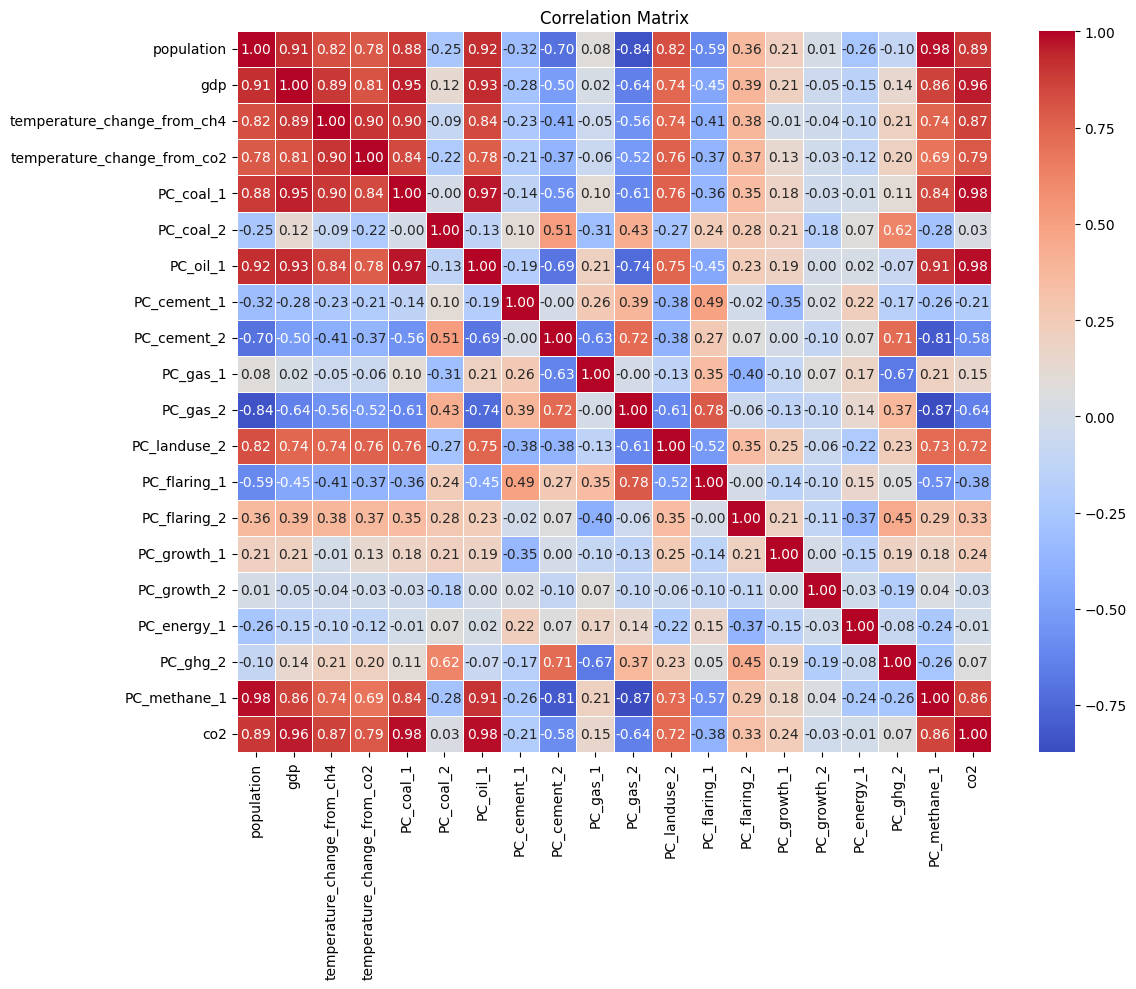

Highly correlated feature pairs:
                      Feature 1                    Feature 2  Correlation
21                    PC_coal_1                          co2     0.984353
6                    population                 PC_methane_1     0.979683
23                     PC_oil_1                          co2     0.979237
19                    PC_coal_1                     PC_oil_1     0.965028
13                          gdp                          co2     0.959742
10                          gdp                    PC_coal_1     0.949730
11                          gdp                     PC_oil_1     0.930153
3                    population                     PC_oil_1     0.924292
0                    population                          gdp     0.912447
22                     PC_oil_1                 PC_methane_1     0.909229
14  temperature_change_from_ch4  temperature_change_from_co2     0.898717
15  temperature_change_from_ch4                    PC_coal_1     0.895310
8    

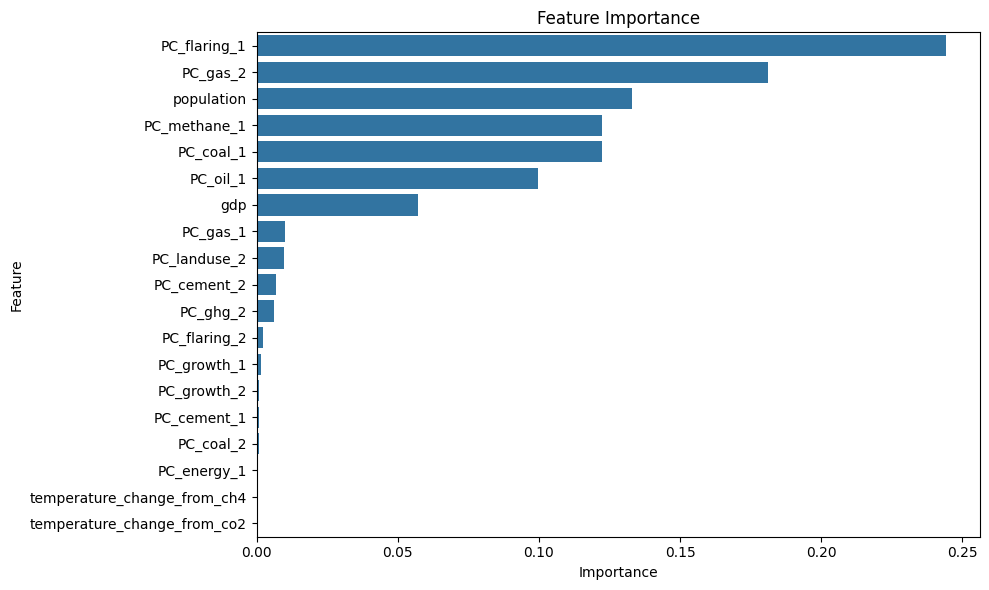

In [78]:
analyze_selected_features(csv_file,[
    'population',
    'gdp',
'temperature_change_from_ch4',
'temperature_change_from_co2',
'PC_coal_1',
'PC_coal_2',
'PC_oil_1',

'PC_cement_1',
'PC_cement_2',
'PC_gas_1',
'PC_gas_2',

'PC_landuse_2',
'PC_flaring_1',
'PC_flaring_2',
'PC_growth_1',
'PC_growth_2',
'PC_energy_1',
'PC_ghg_2',
'PC_methane_1',

]
,target_variable='co2' )

In [6]:
csv_file = os.path.join(output_dir,f'Afghanistan.csv')

columns_to_use = ['year',
    'gdp',
'temperature_change_from_ch4',
'temperature_change_from_co2',
'PC_coal_1',
'PC_coal_2',
'PC_oil_1',
 'PC_oil_2',
'PC_cement_1',
'PC_cement_2',
'PC_gas_1',
'PC_gas_2',
 
'PC_landuse_2',
'PC_flaring_1',
'PC_flaring_2',
'PC_growth_1',
'PC_growth_2',
'PC_energy_1',

'PC_ghg_2',
'PC_methane_1',
'primary_energy_consumption',
'co2_per_capita',
'co2_per_gdp',
'co2_per_unit_energy',

'share_global_co2',

'co2']

df = pd.read_csv(csv_file)

df_final= df[columns_to_use].copy()

print(df_final.isnull().sum())

year                            0
gdp                             2
temperature_change_from_ch4     0
temperature_change_from_co2     0
PC_coal_1                       0
PC_coal_2                       0
PC_oil_1                        0
PC_oil_2                        0
PC_cement_1                     0
PC_cement_2                     0
PC_gas_1                        0
PC_gas_2                        0
PC_landuse_2                    0
PC_flaring_1                    0
PC_flaring_2                    0
PC_growth_1                     0
PC_growth_2                     0
PC_energy_1                     0
PC_ghg_2                        0
PC_methane_1                    0
primary_energy_consumption     33
co2_per_capita                  0
co2_per_gdp                     2
co2_per_unit_energy            33
share_global_co2                0
co2                             0
dtype: int64


In [7]:
def prepare_time_series_data(df, target_col='co2', lags=2, add_polynomial_year=True, window_size=3):
    """
    Prepare time series data with lag variables and polynomial transformations.
    Uses rolling window imputation for missing values instead of dropping rows.
    
    Parameters:
    -----------
    df : DataFrame
        Input dataframe
    target_col : str
        Target variable column name
    lags : int
        Number of lag terms to include
    add_polynomial_year : bool
        Whether to add polynomial transformations of year
    window_size : int
        Size of rolling window for imputation
        
    Returns:
    --------
    DataFrame
        Prepared dataframe
    """
    # Create a copy to avoid modifying the original
    df_prepared = df.copy().sort_values('year')
    
    # First impute the target variable using rolling window method
    df_prepared[target_col] = rolling_window_impute(df_prepared[target_col], window=window_size)
    
    # Add lag variables
    for i in range(1, lags+1):
        df_prepared[f'{target_col}_lag{i}'] = df_prepared[target_col].shift(i)
    
    # Add polynomial year terms if requested
    if add_polynomial_year:
        df_prepared['year_squared'] = df_prepared['year']**2
        df_prepared['year_cubed'] = df_prepared['year']**3
    
    # Log transform the target
    df_prepared[f'log_{target_col}'] = np.log1p(df_prepared[target_col])
    
    # Impute any remaining missing values in all columns
    for col in df_prepared.columns:
        if df_prepared[col].isna().any():
            df_prepared[col] = rolling_window_impute(df_prepared[col], window=window_size)
    
    return df_prepared

def rolling_window_impute(series, window=3):
    """
    Impute missing values using rolling window average.
    
    Parameters:
    -----------
    series : Series
        The pandas Series to impute
    window : int
        Size of the rolling window
        
    Returns:
    --------
    Series
        Imputed series
    """
    imputed = series.copy()
    mask = series.isna()
    
    if mask.any():
        # Create a rolling mean series (ignoring NaNs)
        rolling_mean = series.rolling(window=window, center=True, min_periods=1).mean()
        
        # Fill missing values with rolling mean
        imputed[mask] = rolling_mean[mask]
        
        # If there are still NaN values (e.g., at the start with no prior values)
        # Fill forward and then backward to handle edges
        imputed = imputed.fillna(method='ffill').fillna(method='bfill')
    
    return imputed

def time_series_regression(df, target_col='co2', test_size=0.2, n_splits=5, 
                                alphas=[0.1, 1.0, 10.0, 100.0], lags=2, 
                                add_polynomial_year=True, use_log_transform=True):
    """
    Perform time series ridge regression with cross-validation.
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame containing features and target variable
    target_col : str
        Name of the target column
    test_size : float
        Proportion of data to use for final testing
    n_splits : int
        Number of splits for time series cross-validation
    alphas : list
        Ridge regularization parameters to test
    lags : int
        Number of lag terms to include
    add_polynomial_year : bool
        Whether to add polynomial transformations of year
    use_log_transform : bool
        Whether to use log transformation of target
    
    Returns:
    --------
    dict
        Dictionary containing model, predictions, and evaluation metrics
    """
    # Prepare time series data
    df_prepared = prepare_time_series_data(df, target_col, lags, add_polynomial_year)
    
    # Set the transformed target variable if requested
    if use_log_transform:
        transformed_target = f'log_{target_col}'
    else:
        transformed_target = target_col
    
    # Sort data by year to ensure chronological order
    df_prepared = df_prepared.sort_values('year')
    
    # Separate features and target
    X = df_prepared.drop(columns=[target_col, transformed_target, 'year'])
    y = df_prepared[transformed_target]
    years = df_prepared['year']
    
    # Create train/test split based on the most recent 'test_years' years
    unique_years = sorted(years.unique())
    test_years= 10
    cutoff_year = unique_years[-test_years]
    
    # Split based on years
    train_mask = years < cutoff_year
    test_mask = years >= cutoff_year
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    train_years = years[train_mask]
    test_years = years[test_mask]
    
    print(f"Training data: {train_years.min()} to {train_years.max()}")
    print(f"Testing data: {test_years.min()} to {test_years.max()}")
    
    # Time series cross-validation
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Create pipeline with imputation, scaling and ridge regression
    pipeline = Pipeline([

        ('scaler', StandardScaler()),
        ('lasso', Lasso(max_iter=10000))
    ])
    
    # Cross-validation for alpha selection
    cv_scores = []
    for alpha in alphas:
        fold_scores = []
        pipeline.set_params(lasso__alpha=alpha)
        
        for train_idx, val_idx in tscv.split(X_train):
            # Train on each fold
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            pipeline.fit(X_fold_train, y_fold_train)
            y_fold_pred = pipeline.predict(X_fold_val)
            
            # Calculate RMSE for this fold
            rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
            fold_scores.append(rmse)
        
        # Average score across folds
        avg_rmse = np.mean(fold_scores)
        cv_scores.append(avg_rmse)
        print(f"Alpha = {alpha}, Average RMSE = {avg_rmse:.4f}")
    
    # Find best alpha
    best_alpha_idx = np.argmin(cv_scores)
    best_alpha = alphas[best_alpha_idx]
    print(f"Best alpha: {best_alpha}")
    
    # Train final model with best alpha
    final_pipeline = Pipeline([

        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=best_alpha,max_iter=10000))
    ])
    final_pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_train_pred = final_pipeline.predict(X_train)
    y_test_pred = final_pipeline.predict(X_test)
    
    # Transform predictions back to original scale if using log transform
    if use_log_transform:
        y_train_orig = np.expm1(y_train)
        y_test_orig = np.expm1(y_test)
        y_train_pred_orig = np.expm1(y_train_pred)
        y_test_pred_orig = np.expm1(y_test_pred)
    else:
        y_train_orig = y_train
        y_test_orig = y_test
        y_train_pred_orig = y_train_pred
        y_test_pred_orig = y_test_pred
    
    # Calculate metrics in transformed space
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Calculate metrics in original space
    train_rmse_orig = np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig))
    test_rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
    train_r2_orig = r2_score(y_train_orig, y_train_pred_orig)
    test_r2_orig = r2_score(y_test_orig, y_test_pred_orig)
    
    print(f"\nMetrics in {'log' if use_log_transform else 'original'} space:")
    print(f"Training RMSE: {train_rmse:.4f}")
    print(f"Testing RMSE: {test_rmse:.4f}")
    print(f"Training R²: {train_r2:.4f}")
    print(f"Testing R²: {test_r2:.4f}")
    
    print(f"\nMetrics in original CO2 space:")
    print(f"Training RMSE: {train_rmse_orig:.4f}")
    print(f"Testing RMSE: {test_rmse_orig:.4f}")
    print(f"Training R²: {train_r2_orig:.4f}")
    print(f"Testing R²: {test_r2_orig:.4f}")
    
    # Get feature importances (coefficient magnitudes)
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': np.abs(final_pipeline.named_steps['lasso'].coef_)
    }).sort_values('Coefficient', ascending=False)
    
    print("\nFeature Importance (by coefficient magnitude):")
    print(feature_importance.head(10))
    
    # Visualize results (in original space)
    plt.figure(figsize=(14, 7))
    
    plt.subplot(121)
    plt.plot(train_years, y_train_orig, 'b-', label='Actual')
    plt.plot(train_years, y_train_pred_orig, 'r--', label='Predicted')
    plt.title('Training Data: Actual vs Predicted CO2')
    plt.xlabel('Year')
    plt.ylabel('CO2 Emissions')
    plt.legend()
    
    plt.subplot(122)
    plt.plot(test_years, y_test_orig, 'b-', label='Actual')
    plt.plot(test_years, y_test_pred_orig, 'r--', label='Predicted')
    plt.title('Testing Data: Actual vs Predicted CO2')
    plt.xlabel('Year')
    plt.ylabel('CO2 Emissions')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Plot alpha vs RMSE
    plt.figure(figsize=(10, 6))
    plt.plot(alphas, cv_scores, 'o-')
    plt.xscale('log')
    plt.xlabel('Alpha (log scale)')
    plt.ylabel('Average RMSE')
    plt.title('Alpha Parameter Selection')
    plt.axvline(best_alpha, color='r', linestyle='--', label=f'Best Alpha = {best_alpha}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Create result dictionary
    results = {
        'model': final_pipeline,
        'best_alpha': best_alpha,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse_orig': train_rmse_orig,
        'test_rmse_orig': test_rmse_orig,
        'train_r2_orig': train_r2_orig,
        'test_r2_orig': test_r2_orig,
        'feature_importance': feature_importance,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'y_train_pred_orig': y_train_pred_orig,
        'y_test_pred_orig': y_test_pred_orig,
        'train_years': train_years,
        'test_years': test_years,
        'use_log_transform': use_log_transform,
        'X_columns': list(X.columns)
    }
    
    return results

def forecast_co2_emissions(model, df, years_to_forecast=5, 
                          target_col='co2', use_log_transform=True,
                          window_size=3):
    """
    Forecast CO2 emissions for future years using a more streamlined approach.
    Uses rolling window imputation for any missing historical values.
    
    Parameters:
    -----------
    model : Pipeline
        Trained regression model pipeline
    df : DataFrame
        Original dataframe with historical data
    years_to_forecast : int
        Number of years to forecast
    target_col : str
        Target variable name
    use_log_transform : bool
        Whether log transformation was used
    window_size : int
        Size of rolling window for imputation
    
    Returns:
    --------
    DataFrame
        Forecasted emissions by year
    """

    
    # Sort dataframe by year
    df_sorted = df.copy().sort_values('year')
    
    # Impute any missing values in the historical data using rolling window
    for col in df_sorted.columns:
        if df_sorted[col].isna().any():
            df_sorted[col] = rolling_window_impute(df_sorted[col], window=window_size)
    
    # Get the last year in the data
    last_year = df_sorted['year'].max()
    
    # Get the feature columns used in the model
    feature_names = model.feature_names_in_
    
    # Create a dataframe to store forecasts
    forecast_years = range(int(last_year) + 1, int(last_year) + years_to_forecast + 1)
    forecast_df = pd.DataFrame({'year': forecast_years})
    forecast_values = []
    
    # Get the most recent values to use for prediction
    last_row = df_sorted.iloc[-1].copy()
    prev_co2 = last_row[target_col]
    
    # For each future year
    for i, year in enumerate(forecast_years):
        # Create prediction input with the year and latest known values
        pred_input = {}
        
        # Add the year information
        pred_input['year'] = year
        pred_input['year_squared'] = year**2
        pred_input['year_cubed'] = year**3
        
        # Add lag terms (use previous predictions once available)
        if i == 0:
            # First forecast year - use the last known CO2 value
            pred_input[f'{target_col}_lag1'] = prev_co2
            if f'{target_col}_lag2' in feature_names:
                pred_input[f'{target_col}_lag2'] = df_sorted[target_col].iloc[-2]
        elif i == 1:
            # Second forecast year - use the first prediction and last known CO2
            pred_input[f'{target_col}_lag1'] = forecast_values[0]
            pred_input[f'{target_col}_lag2'] = prev_co2
        else:
            # Later forecast years - use previous predictions
            pred_input[f'{target_col}_lag1'] = forecast_values[i-1]
            pred_input[f'{target_col}_lag2'] = forecast_values[i-2]
            
        # For all other features, use the last known values
        for feature in feature_names:
            if feature not in pred_input and feature not in [f'{target_col}_lag1', f'{target_col}_lag2']:
                if feature in last_row.index:
                    pred_input[feature] = last_row[feature]
                else:
                    # Use column mean if feature not in last row
                    pred_input[feature] = df_sorted[feature].mean() if feature in df_sorted.columns else 0
        
        # Create a DataFrame with the prediction input
        pred_df = pd.DataFrame([pred_input])
        
        # Ensure all required features are present and in the right order
        pred_features = pred_df[feature_names].copy()
        
        # Make the prediction
        try:
            # Predict CO2 value
            prediction = model.predict(pred_features)[0]
            
            # Convert back from log scale if needed
            if use_log_transform:
                co2_forecast = np.expm1(prediction)
            else:
                co2_forecast = prediction
                
            forecast_values.append(co2_forecast)
            
        except Exception as e:
            print(f"Error predicting for year {year}: {str(e)}")
            # Use trend continuation as fallback
            if i > 0:
                # Use previous prediction with same growth rate
                prev_growth = forecast_values[i-1] / (forecast_values[i-2] if i > 1 else prev_co2)
                co2_forecast = forecast_values[i-1] * prev_growth
            else:
                # Use last observed value
                co2_forecast = prev_co2
                
            forecast_values.append(co2_forecast)
    
    # Add forecasts to the result dataframe
    forecast_df[target_col] = forecast_values
    
    return forecast_df


Training data: 1949 to 2013
Testing data: 2014 to 2023
Alpha = 0.0001, Average RMSE = 1649645603082.3516
Alpha = 0.001, Average RMSE = 0.2125
Alpha = 0.01, Average RMSE = 0.1098
Alpha = 0.1, Average RMSE = 0.2108
Alpha = 1.0, Average RMSE = 0.6216
Alpha = 10.0, Average RMSE = 0.6216
Alpha = 100.0, Average RMSE = 0.6216
Alpha = 1000.0, Average RMSE = 0.6216
Alpha = 10000.0, Average RMSE = 0.6216
Best alpha: 0.01

Metrics in log space:
Training RMSE: 0.0437
Testing RMSE: 0.0889
Training R²: 0.9939
Testing R²: -0.4408

Metrics in original CO2 space:
Training RMSE: 0.2444
Testing RMSE: 1.0579
Training R²: 0.9887
Testing R²: -0.6460

Feature Importance (by coefficient magnitude):
             Feature  Coefficient
20    co2_per_capita     0.154531
0                gdp     0.153379
23  share_global_co2     0.096217
21       co2_per_gdp     0.088414
8        PC_cement_2     0.073228
18      PC_methane_1     0.064213
7        PC_cement_1     0.025381
26      year_squared     0.013362
13      PC

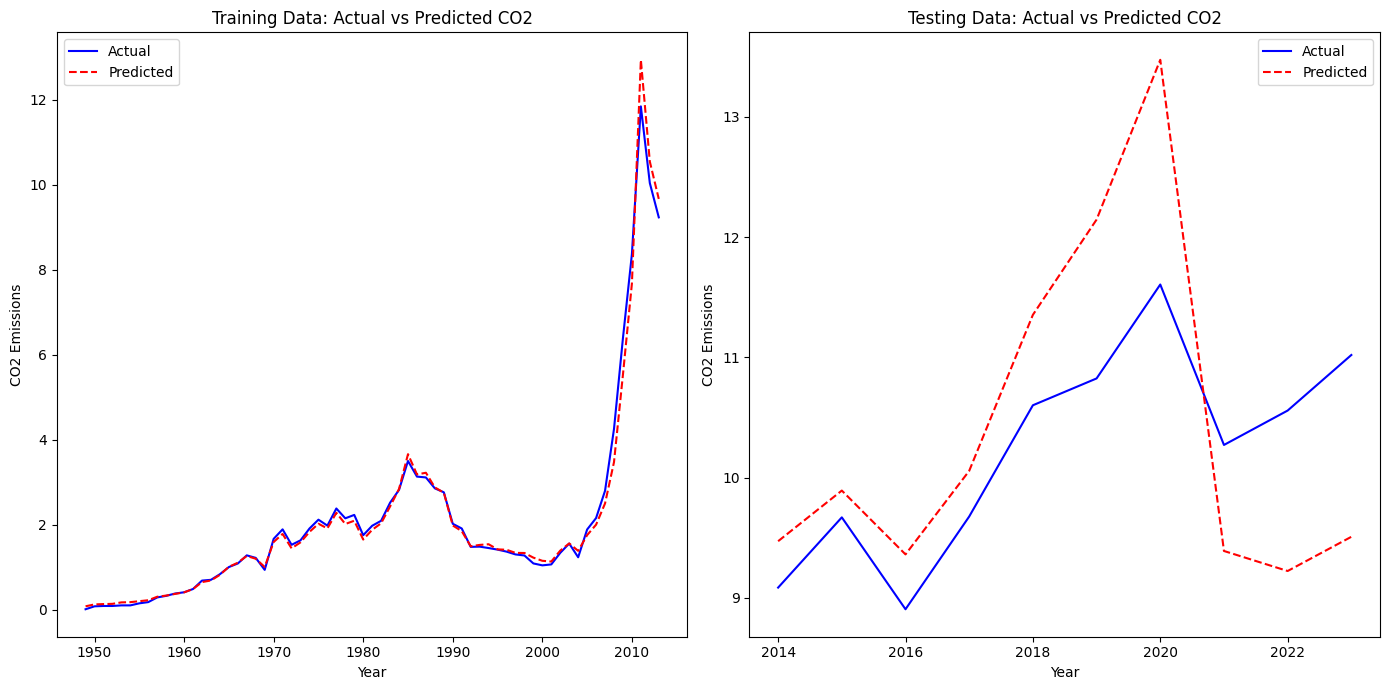

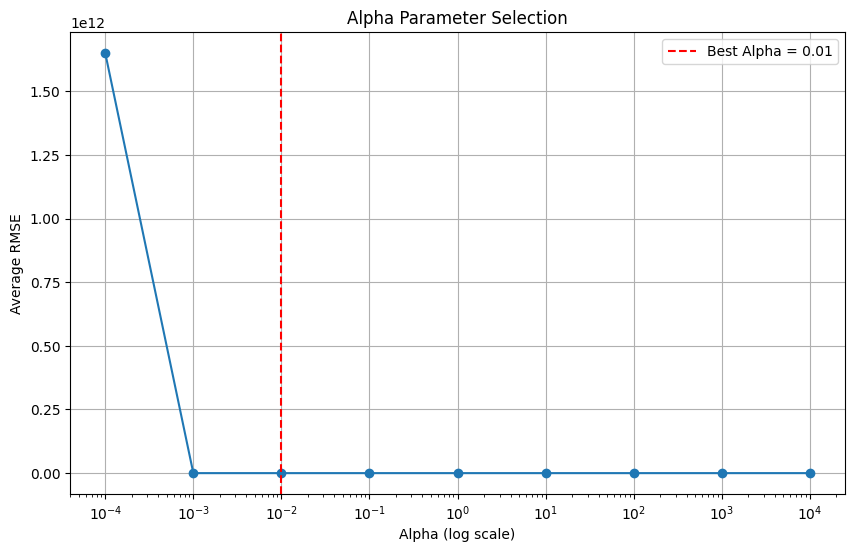

   year       co2
0  2024  9.516019
1  2025  9.523676
2  2026  9.531342
3  2027  9.539018
4  2028  9.546703
5  2029  9.554397
6  2030  9.562101
7  2031  9.569815
8  2032  9.577537
9  2033  9.585269


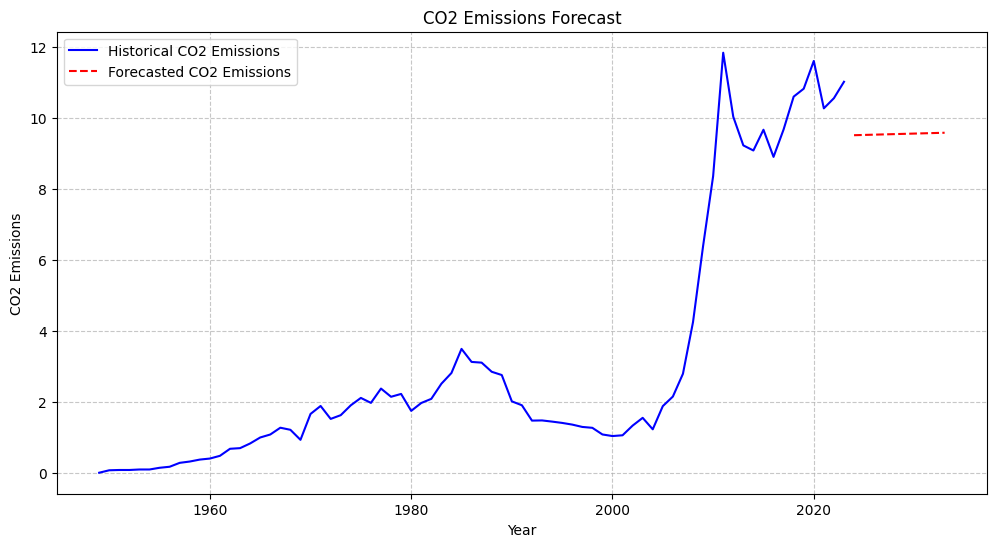

In [104]:
results = time_series_regression(df_final, target_col='co2', 
                                      alphas=[0.0001,0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0,10000.0],
                                      lags=2, add_polynomial_year=True, use_log_transform=True)

forecast = forecast_co2_emissions(results['model'],df_final,years_to_forecast=10,target_col='co2')

# Display the forecasts
print(forecast)

# Visualize historical data and forecasts
plt.figure(figsize=(12, 6))
plt.plot(df_final['year'], df_final['co2'], 'b-', label='Historical CO2 Emissions')
plt.plot(forecast['year'], forecast['co2'], 'r--', label='Forecasted CO2 Emissions')
plt.title('CO2 Emissions Forecast')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
def time_series_elasticnet(df, target_col='co2', test_size=0.2, n_splits=5, 
                          alphas=[0.1, 1.0, 10.0, 100.0], l1_ratios=[0.1, 0.5, 0.7, 0.9], 
                          lags=2, add_polynomial_year=True, use_log_transform=True):
    """
    Perform time series ElasticNet regression with cross-validation.
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame containing features and target variable
    target_col : str
        Name of the target column
    test_size : float
        Proportion of data to use for final testing
    n_splits : int
        Number of splits for time series cross-validation
    alphas : list
        ElasticNet regularization parameters to test
    l1_ratios : list
        ElasticNet L1 ratio parameters to test (1 = Lasso, 0 = Ridge)
    lags : int
        Number of lag terms to include
    add_polynomial_year : bool
        Whether to add polynomial transformations of year
    use_log_transform : bool
        Whether to use log transformation of target
    
    Returns:
    --------
    dict
        Dictionary containing model, predictions, and evaluation metrics
    """
    # Prepare time series data - reuse your existing function
    df_prepared = prepare_time_series_data(df, target_col, lags, add_polynomial_year)
    
    # Set the transformed target variable if requested
    if use_log_transform:
        transformed_target = f'log_{target_col}'
    else:
        transformed_target = target_col
    
    # Sort data by year to ensure chronological order
    df_prepared = df_prepared.sort_values('year')
    
    # Separate features and target
    X = df_prepared.drop(columns=[target_col, transformed_target, 'year'])
    y = df_prepared[transformed_target]
    years = df_prepared['year']
    
    # Create train/test split based on the most recent 'test_years' years
    unique_years = sorted(years.unique())
    test_years = 10
    cutoff_year = unique_years[-test_years]
    
    # Split based on years
    train_mask = years < cutoff_year
    test_mask = years >= cutoff_year
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    train_years = years[train_mask]
    test_years = years[test_mask]
    
    print(f"Training data: {train_years.min()} to {train_years.max()}")
    print(f"Testing data: {test_years.min()} to {test_years.max()}")
    
    # Enhanced time-based cross-validation
    # Get unique years in the training data
    unique_train_years = sorted(train_years.unique())
    n_years = len(unique_train_years)
    
    # Ensure we have enough years for the requested splits
    effective_splits = min(n_splits, n_years - 2)  # Need at least 2 years (1 train, 1 val)
    if effective_splits < n_splits:
        print(f"Warning: Requested {n_splits} splits but data only supports {effective_splits}.")
    
    # Create custom time-based fold indices
    time_folds = []
    min_train_size = 3  # Minimum years required for training
    
    # Calculate fold sizes to ensure proper increasing window approach
    for i in range(effective_splits):
        # For expanding window approach: increase training size as folds progress
        # i=0: first fold uses min_train_size years, last fold uses all but 1 year
        if n_years > min_train_size + effective_splits:
            # If we have enough years, use an expanding window
            n_train_years = min_train_size + i
            cutoff_year = unique_train_years[n_train_years]
            
            # Create masks for this fold
            train_years_mask = (train_years < cutoff_year)
            val_years_mask = (train_years >= cutoff_year) & (train_years < unique_train_years[n_train_years + 1])
            
            train_indices = np.where(train_years_mask)[0]
            val_indices = np.where(val_years_mask)[0]
            
            time_folds.append((train_indices, val_indices))
            
            print(f"Fold {i+1}: Train years {train_years[train_indices].min()} to {train_years[train_indices].max()}, "
                  f"Val year {train_years[val_indices].min()} to {train_years[val_indices].max()}")
        else:
            # If we don't have enough years, use sliding window
            start_idx = i
            train_end_idx = start_idx + min_train_size
            val_idx = train_end_idx
            
            if val_idx < n_years:
                train_years_mask = (train_years >= unique_train_years[start_idx]) & (train_years < unique_train_years[train_end_idx])
                val_years_mask = (train_years >= unique_train_years[val_idx]) & (train_years < unique_train_years[val_idx + 1])
                
                train_indices = np.where(train_years_mask)[0]
                val_indices = np.where(val_years_mask)[0]
                
                time_folds.append((train_indices, val_indices))
                
                print(f"Fold {i+1}: Train years {train_years[train_indices].min()} to {train_years[train_indices].max()}, "
                      f"Val year {train_years[val_indices].min()} to {train_years[val_indices].max()}")
    
    # Create pipeline with scaling and ElasticNet regression
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('elasticnet', ElasticNet(max_iter=10000, random_state=42))
    ])
    
    # Cross-validation for hyperparameter selection
    best_score = float('inf')
    best_params = {'alpha': None, 'l1_ratio': None}
    cv_results = []
    
    for alpha in alphas:
        for l1_ratio in l1_ratios:
            fold_scores = []
            fold_times = []
            pipeline.set_params(elasticnet__alpha=alpha, elasticnet__l1_ratio=l1_ratio)
            
            for fold_idx, (train_idx, val_idx) in enumerate(time_folds):
                # Train on each fold
                X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                fold_train_years = train_years.iloc[train_idx]
                fold_val_years = train_years.iloc[val_idx]
                
                # Track predictions for this fold
                train_years_for_fold = []
                val_years_for_fold = []
                train_actuals = []
                val_actuals = []
                train_preds = []
                val_preds = []
                
                # Fit model and make predictions
                pipeline.fit(X_fold_train, y_fold_train)
                y_fold_train_pred = pipeline.predict(X_fold_train)
                y_fold_val_pred = pipeline.predict(X_fold_val)
                
                # Store predictions for later analysis
                train_years_for_fold.extend(fold_train_years)
                val_years_for_fold.extend(fold_val_years)
                train_actuals.extend(y_fold_train)
                val_actuals.extend(y_fold_val)
                train_preds.extend(y_fold_train_pred)
                val_preds.extend(y_fold_val_pred)
                
                # Calculate RMSE for this fold
                rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_val_pred))
                fold_scores.append(rmse)
                fold_times.append(fold_val_years.mean())
                
                # Store results for this parameter combination and fold
                cv_results.append({
                    'alpha': alpha,
                    'l1_ratio': l1_ratio,
                    'fold': fold_idx + 1,
                    'train_years': f"{fold_train_years.min()} - {fold_train_years.max()}",
                    'val_years': f"{fold_val_years.min()} - {fold_val_years.max()}",
                    'rmse': rmse,
                    'train_actuals': train_actuals,
                    'val_actuals': val_actuals,
                    'train_preds': train_preds,
                    'val_preds': val_preds
                })
            
            # Weight recent years more (optional)
            weights = np.linspace(0.5, 1.0, len(fold_scores))  # Increase weights for recent periods
            weighted_rmse = np.average(fold_scores, weights=weights)
            
            # Regular average
            avg_rmse = np.mean(fold_scores)
            
            print(f"Alpha = {alpha}, L1 Ratio = {l1_ratio}, "
                  f"Average RMSE = {avg_rmse:.4f}, Weighted RMSE = {weighted_rmse:.4f}")
            
            if avg_rmse < best_score:
                best_score = avg_rmse
                best_params = {'alpha': alpha, 'l1_ratio': l1_ratio}
    
    # Create DataFrame with CV results for analysis
    cv_results_df = pd.DataFrame(cv_results)
    
    # Find best parameters based on weighted average RMSE
    cv_summary = cv_results_df.groupby(['alpha', 'l1_ratio'])['rmse'].agg(['mean', 'std'])
    cv_summary.reset_index(inplace=True)
    
    # Optionally, plot CV results for each fold
    plt.figure(figsize=(14, 8))
    sns.boxplot(x='alpha', y='rmse', hue='l1_ratio', data=cv_results_df)
    plt.xscale('log')
    plt.title('Cross-Validation RMSE by Alpha and L1 Ratio')
    plt.xlabel('Alpha (log scale)')
    plt.ylabel('RMSE')
    plt.tight_layout()
    plt.show()
    
    # Select best parameters
    best_params_row = cv_summary.loc[cv_summary['mean'].idxmin()]
    best_params = {
        'alpha': best_params_row['alpha'],
        'l1_ratio': best_params_row['l1_ratio']
    }
    
    print(f"\nBest parameters: Alpha = {best_params['alpha']}, L1 Ratio = {best_params['l1_ratio']}")
    print(f"Mean RMSE: {best_params_row['mean']:.4f}, Std: {best_params_row['std']:.4f}")
    
    # Train final model with best parameters
    final_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('elasticnet', ElasticNet(alpha=best_params['alpha'], 
                                 l1_ratio=best_params['l1_ratio'],
                                 max_iter=10000,
                                 random_state=42))
    ])
    final_pipeline.fit(X_train, y_train)
    
    # Optional: Plot learning curves to detect overfitting
    # Create a TimeSeriesSplit object for the learning curve function
    learning_cv = TimeSeriesSplit(n_splits=min(5, effective_splits))
    
    train_sizes = np.linspace(0.3, 1.0, 7)
    train_sizes_abs, train_scores, test_scores = learning_curve(
        final_pipeline, X_train, y_train, 
        train_sizes=train_sizes, cv=learning_cv, 
        scoring='neg_root_mean_squared_error')
    
    train_scores_mean = -np.mean(train_scores, axis=1)
    test_scores_mean = -np.mean(test_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', label='Training RMSE')
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', label='CV RMSE')
    plt.xlabel('Training Examples')
    plt.ylabel('RMSE')
    plt.title('Learning Curves for ElasticNet Model')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Make predictions
    y_train_pred = final_pipeline.predict(X_train)
    y_test_pred = final_pipeline.predict(X_test)
    
    # Transform predictions back to original scale if using log transform
    if use_log_transform:
        y_train_orig = np.expm1(y_train)
        y_test_orig = np.expm1(y_test)
        y_train_pred_orig = np.expm1(y_train_pred)
        y_test_pred_orig = np.expm1(y_test_pred)
    else:
        y_train_orig = y_train
        y_test_orig = y_test
        y_train_pred_orig = y_train_pred
        y_test_pred_orig = y_test_pred
    
    # Calculate metrics in transformed space
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # Calculate metrics in original space
    train_rmse_orig = np.sqrt(mean_squared_error(y_train_orig, y_train_pred_orig))
    test_rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_test_pred_orig))
    train_r2_orig = r2_score(y_train_orig, y_train_pred_orig)
    test_r2_orig = r2_score(y_test_orig, y_test_pred_orig)
    
    print(f"\nMetrics in {'log' if use_log_transform else 'original'} space:")
    print(f"Training RMSE: {train_rmse:.4f}")
    print(f"Testing RMSE: {test_rmse:.4f}")
    print(f"Training R²: {train_r2:.4f}")
    print(f"Testing R²: {test_r2:.4f}")
    
    print(f"\nMetrics in original CO2 space:")
    print(f"Training RMSE: {train_rmse_orig:.4f}")
    print(f"Testing RMSE: {test_rmse_orig:.4f}")
    print(f"Training R²: {train_r2_orig:.4f}")
    print(f"Testing R²: {test_r2_orig:.4f}")
    
    # Calculate and display feature importances
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Coefficient': np.abs(final_pipeline.named_steps['elasticnet'].coef_)
    }).sort_values('Coefficient', ascending=False)
    
    print("\nFeature Importance (by coefficient magnitude):")
    print(feature_importance.head(10))
    
    # Visualize actual vs predicted values
    plt.figure(figsize=(14, 7))
    
    plt.subplot(121)
    plt.plot(train_years, y_train_orig, 'b-', label='Actual')
    plt.plot(train_years, y_train_pred_orig, 'r--', label='Predicted')
    plt.title('Training Data: Actual vs Predicted CO2')
    plt.xlabel('Year')
    plt.ylabel('CO2 Emissions')
    plt.legend()
    
    plt.subplot(122)
    plt.plot(test_years, y_test_orig, 'b-', label='Actual')
    plt.plot(test_years, y_test_pred_orig, 'r--', label='Predicted')
    plt.title('Testing Data: Actual vs Predicted CO2')
    plt.xlabel('Year')
    plt.ylabel('CO2 Emissions')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Visualize parameter selection
    param_grid = [(alpha, l1) for alpha in alphas for l1 in l1_ratios]
    all_scores = []
    
    for alpha in alphas:
        for l1_ratio in l1_ratios:
            fold_scores = []
            pipeline.set_params(elasticnet__alpha=alpha, elasticnet__l1_ratio=l1_ratio)
            
            for train_idx, val_idx in tscv.split(X_train):
                X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                
                pipeline.fit(X_fold_train, y_fold_train)
                y_fold_pred = pipeline.predict(X_fold_val)
                rmse = np.sqrt(mean_squared_error(y_fold_val, y_fold_pred))
                fold_scores.append(rmse)
            
            all_scores.append(np.mean(fold_scores))
    
    # Plot heatmap of parameter combinations
    scores_matrix = np.array(all_scores).reshape(len(alphas), len(l1_ratios))
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(scores_matrix, annot=True, fmt=".4f", 
                xticklabels=l1_ratios, yticklabels=alphas, 
                cmap="YlGnBu", cbar_kws={'label': 'RMSE'})
    plt.xlabel('L1 Ratio')
    plt.ylabel('Alpha')
    plt.title('ElasticNet Parameter Selection: RMSE by Alpha and L1 Ratio')
    plt.tight_layout()
    plt.show()
    
    # Create result dictionary
    results = {
        'model': final_pipeline,
        'best_params': best_params,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse_orig': train_rmse_orig,
        'test_rmse_orig': test_rmse_orig,
        'train_r2_orig': train_r2_orig,
        'test_r2_orig': test_r2_orig,
        'feature_importance': feature_importance,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'y_train_pred_orig': y_train_pred_orig,
        'y_test_pred_orig': y_test_pred_orig,
        'train_years': train_years,
        'test_years': test_years,
        'use_log_transform': use_log_transform,
        'X_columns': list(X.columns)
    }
    
    return results


# Modify the forecast function to work with the ElasticNet model
def forecast_co2_elasticnet(model, df, years_to_forecast=5, 
                           target_col='co2', use_log_transform=True,
                           window_size=3):
    """
    Forecast CO2 emissions for future years using the trained ElasticNet model.
    Uses rolling window imputation for any missing historical values.
    
    Parameters:
    -----------
    model : Pipeline
        Trained ElasticNet model pipeline
    df : DataFrame
        Original dataframe with historical data
    years_to_forecast : int
        Number of years to forecast
    target_col : str
        Target variable name
    use_log_transform : bool
        Whether log transformation was used
    window_size : int
        Size of rolling window for imputation
    
    Returns:
    --------
    DataFrame
        Forecasted emissions by year
    """
    # Sort dataframe by year
    df_sorted = df.copy().sort_values('year')
    
    # Impute any missing values in the historical data using rolling window
    for col in df_sorted.columns:
        if df_sorted[col].isna().any():
            df_sorted[col] = rolling_window_impute(df_sorted[col], window=window_size)
    
    # Get the last year in the data
    last_year = df_sorted['year'].max()
    
    # Get the feature columns used in the model
    feature_names = model.feature_names_in_
    
    # Create a dataframe to store forecasts
    forecast_years = range(int(last_year) + 1, int(last_year) + years_to_forecast + 1)
    forecast_df = pd.DataFrame({'year': forecast_years})
    forecast_values = []
    forecast_conf_intervals = []
    
    # Get the most recent values to use for prediction
    last_row = df_sorted.iloc[-1].copy()
    prev_co2 = last_row[target_col]
    
    # For each future year
    for i, year in enumerate(forecast_years):
        # Create prediction input with the year and latest known values
        pred_input = {}
        
        # Add the year information
        pred_input['year'] = year
        pred_input['year_squared'] = year**2
        pred_input['year_cubed'] = year**3
        
        # Add lag terms (use previous predictions once available)
        if i == 0:
            # First forecast year - use the last known CO2 value
            pred_input[f'{target_col}_lag1'] = prev_co2
            if f'{target_col}_lag2' in feature_names:
                pred_input[f'{target_col}_lag2'] = df_sorted[target_col].iloc[-2]
        elif i == 1:
            # Second forecast year - use the first prediction and last known CO2
            pred_input[f'{target_col}_lag1'] = forecast_values[0]
            pred_input[f'{target_col}_lag2'] = prev_co2
        else:
            # Later forecast years - use previous predictions
            pred_input[f'{target_col}_lag1'] = forecast_values[i-1]
            pred_input[f'{target_col}_lag2'] = forecast_values[i-2]
            
        # For all other features, use the last known values
        for feature in feature_names:
            if feature not in pred_input and feature not in [f'{target_col}_lag1', f'{target_col}_lag2']:
                if feature in last_row.index:
                    pred_input[feature] = last_row[feature]
                else:
                    # Use column mean if feature not in last row
                    pred_input[feature] = df_sorted[feature].mean() if feature in df_sorted.columns else 0
        
        # Create a DataFrame with the prediction input
        pred_df = pd.DataFrame([pred_input])
        
        # Ensure all required features are present and in the right order
        pred_features = pred_df[feature_names].copy()
        
        # Make the prediction
        try:
            # Predict CO2 value
            prediction = model.predict(pred_features)[0]
            
            # Convert back from log scale if needed
            if use_log_transform:
                co2_forecast = np.expm1(prediction)
            else:
                co2_forecast = prediction
                
            forecast_values.append(co2_forecast)
            
            # Estimate prediction interval (simple approximation)
            # This is a crude approximation based on historical error
            pred_std = np.sqrt(np.mean((model.predict(X_test) - y_test)**2))
            lower_bound = np.expm1(prediction - 1.96 * pred_std) if use_log_transform else prediction - 1.96 * pred_std
            upper_bound = np.expm1(prediction + 1.96 * pred_std) if use_log_transform else prediction + 1.96 * pred_std
            forecast_conf_intervals.append((lower_bound, upper_bound))
            
        except Exception as e:
            print(f"Error predicting for year {year}: {str(e)}")
            # Use trend continuation as fallback
            if i > 0:
                # Use previous prediction with same growth rate
                prev_growth = forecast_values[i-1] / (forecast_values[i-2] if i > 1 else prev_co2)
                co2_forecast = forecast_values[i-1] * prev_growth
            else:
                # Use last observed value
                co2_forecast = prev_co2
                
            forecast_values.append(co2_forecast)
            forecast_conf_intervals.append((co2_forecast * 0.9, co2_forecast * 1.1))  # Fallback interval
    
    # Add forecasts to the result dataframe
    forecast_df[target_col] = forecast_values
    forecast_df['lower_bound'] = [interval[0] for interval in forecast_conf_intervals]
    forecast_df['upper_bound'] = [interval[1] for interval in forecast_conf_intervals]
    
    # Visualize forecast with confidence intervals
    plt.figure(figsize=(12, 8))
    
    # Plot historical data
    hist_years = df_sorted['year'].values
    hist_values = df_sorted[target_col].values
    plt.plot(hist_years, hist_values, 'b-', label='Historical Data')
    
    # Plot forecast
    plt.plot(forecast_df['year'], forecast_df[target_col], 'r--', label='Forecast')
    
    # Plot confidence intervals
    plt.fill_between(forecast_df['year'], 
                     forecast_df['lower_bound'], 
                     forecast_df['upper_bound'], 
                     color='red', alpha=0.2, label='Confidence Interval')
    
    plt.title(f'CO2 Emissions Forecast for {years_to_forecast} Years')
    plt.xlabel('Year')
    plt.ylabel('CO2 Emissions')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return forecast_df

Training data: 1949 to 2013
Testing data: 2014 to 2023
Fold 1: Train years 1949 to 1951, Val year 1952 to 1952
Fold 2: Train years 1949 to 1952, Val year 1953 to 1953
Fold 3: Train years 1949 to 1953, Val year 1954 to 1954
Fold 4: Train years 1949 to 1954, Val year 1955 to 1955
Fold 5: Train years 1949 to 1955, Val year 1956 to 1956
Alpha = 0.001, L1 Ratio = 0.1, Average RMSE = 0.0063, Weighted RMSE = 0.0064
Alpha = 0.001, L1 Ratio = 0.3, Average RMSE = 0.0046, Weighted RMSE = 0.0049
Alpha = 0.001, L1 Ratio = 0.5, Average RMSE = 0.0050, Weighted RMSE = 0.0054
Alpha = 0.001, L1 Ratio = 0.7, Average RMSE = 0.0052, Weighted RMSE = 0.0057
Alpha = 0.001, L1 Ratio = 0.9, Average RMSE = 0.0064, Weighted RMSE = 0.0066
Alpha = 0.01, L1 Ratio = 0.1, Average RMSE = 0.0067, Weighted RMSE = 0.0074
Alpha = 0.01, L1 Ratio = 0.3, Average RMSE = 0.0073, Weighted RMSE = 0.0088
Alpha = 0.01, L1 Ratio = 0.5, Average RMSE = 0.0099, Weighted RMSE = 0.0116
Alpha = 0.01, L1 Ratio = 0.7, Average RMSE = 0.0132,

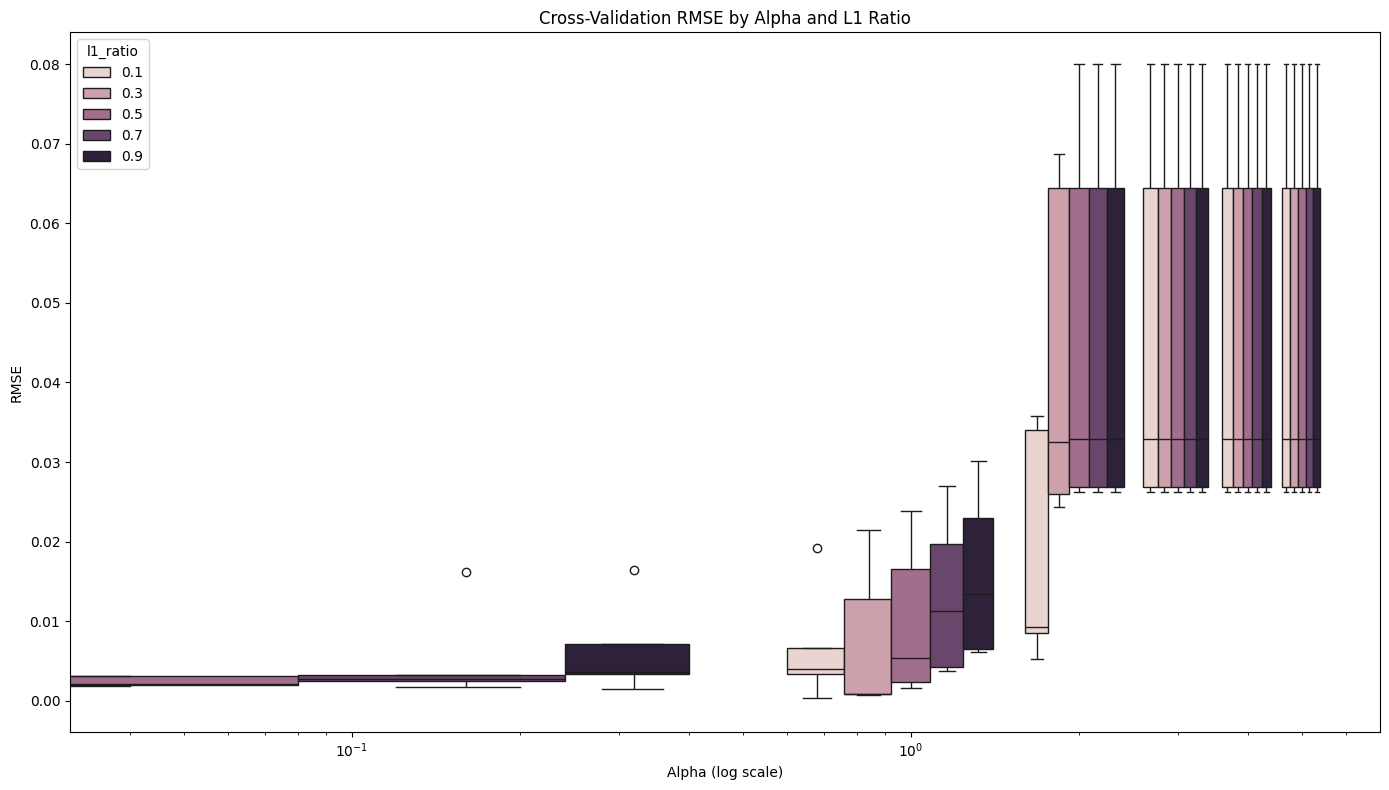


Best parameters: Alpha = 0.001, L1 Ratio = 0.3
Mean RMSE: 0.0046, Std: 0.0064


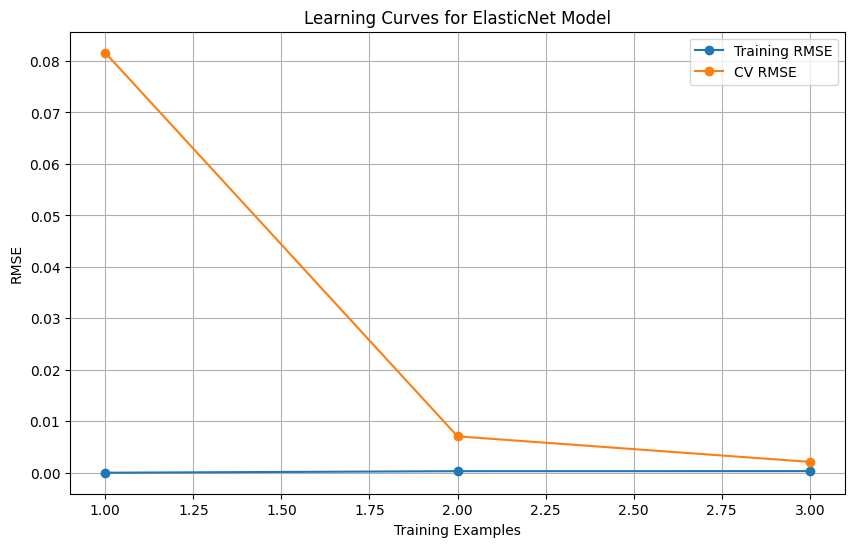


Metrics in log space:
Training RMSE: 0.0223
Testing RMSE: 0.1608
Training R²: 0.9984
Testing R²: -3.7131

Metrics in original CO2 space:
Training RMSE: 0.1061
Testing RMSE: 1.7621
Training R²: 0.9979
Testing R²: -3.5665

Feature Importance (by coefficient magnitude):
             Feature  Coefficient
0                gdp     0.307961
21       co2_per_gdp     0.156427
8        PC_cement_2     0.079497
23  share_global_co2     0.059300
20    co2_per_capita     0.052521
27      year_squared     0.047232
7        PC_cement_1     0.045235
12      PC_flaring_1     0.032465
6           PC_oil_2     0.024377
25          co2_lag2     0.022722


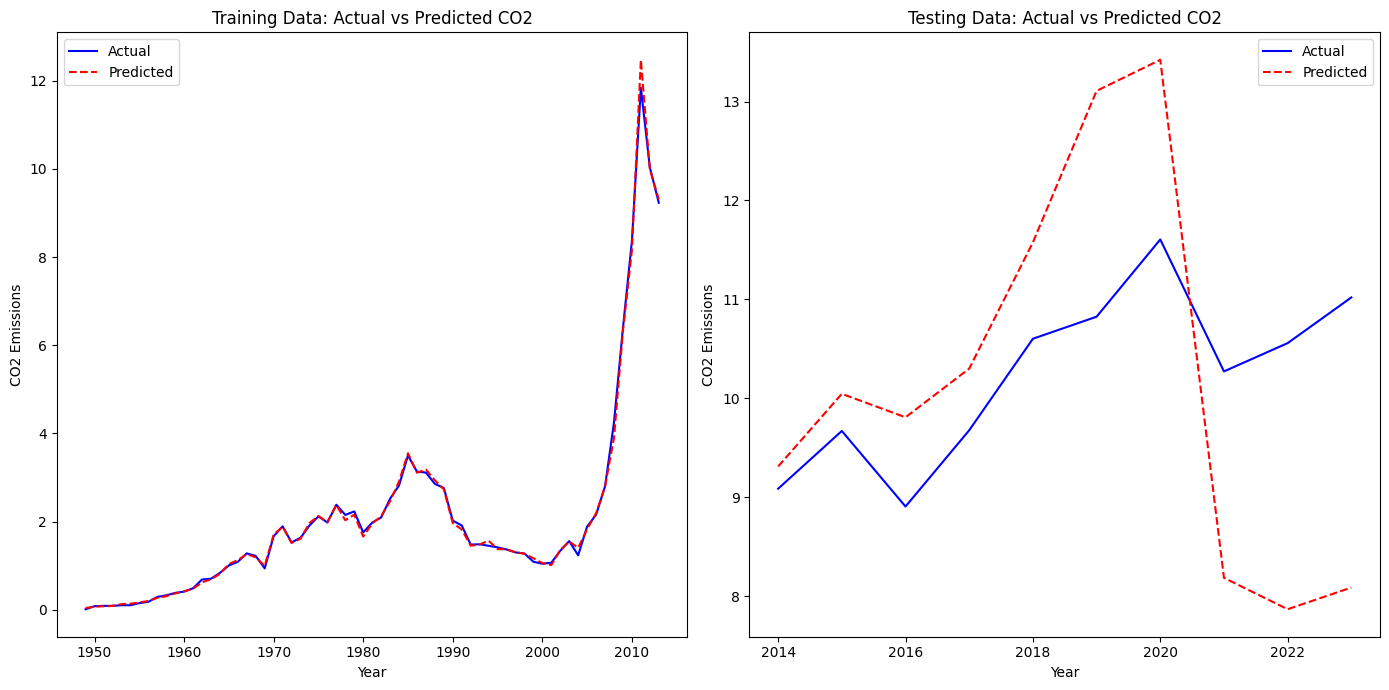

NameError: name 'tscv' is not defined

In [11]:
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
lags = 3
add_polynomial_year = True
use_log_transform = True

# Run ElasticNet model
elasticnet_results = time_series_elasticnet(
    df_final, 
    target_col='co2',  
    alphas=alphas,
    l1_ratios=l1_ratios,
    lags=lags,
    add_polynomial_year=add_polynomial_year,
    use_log_transform=use_log_transform
)

# Generate forecast
forecast_df = forecast_co2_elasticnet(
    elasticnet_results['model'], 
    df_final, 
    years_to_forecast=10
)